In [ ]:
#%% Load Library

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [ ]:
#%% Function

def createXY(dataset,n_past):
    dataX = []
    dataY = []
    for i in range(n_past, len(dataset)):
            dataX.append(dataset[i - n_past:i, 0:dataset.shape[1]])
            dataY.append(dataset[i,0])
    return np.array(dataX),np.array(dataY) 

def prepare_data(dir, store_id):
    df = pd.read_csv(dir,parse_dates = ["date"], index_col = [0])
    df = df[df['store_id'] == store_id]
    df = df.drop(columns=['count','store_id'])
    for col in df.columns:
        if df[col].dtype == bool:
            df[col] = df[col].astype(int)

    test_split=round(len(df)*0.20)
    df_for_training=df[:-test_split]
    df_for_testing=df[-test_split:]
    

    df_for_training_scaled = scaler.fit_transform(df_for_training)
    df_for_testing_scaled=scaler.transform(df_for_testing)
    trainX,trainY=createXY(df_for_training_scaled,30)

    testX,testY=createXY(df_for_testing_scaled,30)
    return trainX, trainY, testX, testY

def build_model(optimizer='adam'):
    grid_model = Sequential()
    grid_model.add(LSTM(50, return_sequences=True, input_shape=(30, 64)))
    grid_model.add(LSTM(50))
    grid_model.add(Dropout(0.2))
    grid_model.add(Dense(1))

    grid_model.compile(loss='mse', optimizer=optimizer)
    return grid_model

def train_model(model, train_x, train_y):

    grid_model = KerasRegressor(build_fn=model, verbose=1)
    parameters = {'batch_size': [16, 20],
                'epochs': [8, 10],
                'optimizer': ['adam', 'Adadelta']}

    grid_search = GridSearchCV(estimator=grid_model,
                            param_grid=parameters,
                            cv=2)
    grid_search = grid_search.fit(train_x, train_y)

    return grid_search

def calculate_permutation_importance(model, X, y, feature_names, n_repeats=10, random_state=42):
    """
    Calculate permutation importance for an LSTM model.
    
    Parameters:
    -----------
    model : Keras model
        Trained LSTM model
    X : numpy array
        Feature data in the shape expected by the LSTM model
    y : numpy array
        Target values
    feature_names : list
        Names of features corresponding to the last dimension of X
    n_repeats : int, default=10
        Number of times to permute each feature
    random_state : int, default=42
        Random seed for reproducibility
    
    Returns:
    --------
    dict
        Dictionary with feature names as keys and importance scores as values
    """
    import numpy as np
    from sklearn.metrics import mean_squared_error
    import copy
    import random
    
    # Set random seed for reproducibility
    np.random.seed(random_state)
    random.seed(random_state)
    
    # Calculate baseline score
    baseline_pred = model.predict(X)
    baseline_score = mean_squared_error(y, baseline_pred)
    
    # Store importance scores
    importance_dict = {}
    
    # Get the feature dimension (assuming X shape is [samples, timesteps, features])
    n_samples, n_timesteps, n_features = X.shape
    
    # Verify feature_names length matches n_features
    if len(feature_names) != n_features:
        raise ValueError(f"Length of feature_names ({len(feature_names)}) doesn't match number of features in X ({n_features})")
    
    # Calculate importance for each feature
    for feature_idx in range(n_features):
        feature_name = feature_names[feature_idx]
        importance_scores = []
        
        for _ in range(n_repeats):
            # Create a copy of the data
            X_permuted = copy.deepcopy(X)
            
            # Permute the feature across all timesteps
            for t in range(n_timesteps):
                perm_idx = np.random.permutation(n_samples)
                X_permuted[:, t, feature_idx] = X_permuted[perm_idx, t, feature_idx]
            
            # Predict with permuted feature
            perm_pred = model.predict(X_permuted)
            
            # Calculate new score
            perm_score = mean_squared_error(y, perm_pred)
            
            # Calculate importance (increase in error)
            importance = perm_score - baseline_score
            importance_scores.append(importance)
        
        # Average importance across repeats
        importance_dict[feature_name] = np.mean(importance_scores)
    
    # Normalize to sum to 1 (optional)
    total_importance = sum(importance_dict.values())
    if total_importance > 0:  # Avoid division by zero
        for feature in importance_dict:
            importance_dict[feature] /= total_importance
    
    # Sort by importance (descending)
    importance_dict = dict(sorted(importance_dict.items(), key=lambda item: item[1], reverse=True))
    
    return importance_dict



def calculate_feature_importance(store, model, testX, testY, feature_names):
    """
    Wrapper function to calculate and visualize feature importance
    """
    import matplotlib.pyplot as plt
    
    # Calculate permutation importance
    importance_dict = calculate_permutation_importance(model, testX, testY, feature_names)
    
    # Print importance scores
    print(f"\nFeature Importance for Store {store}:")
    for feature, importance in importance_dict.items():
        print(f"{feature}: {importance:.4f}")
    
    # Plot feature importance
    plt.figure(figsize=(15, 10))
    features = list(importance_dict.keys())
    importances = list(importance_dict.values())
    
    plt.barh(features, importances)
    plt.xlabel('Importance')
    plt.title(f'Feature Importance for Store {store}')
    plt.tight_layout()
    plt.savefig(f'feature_importance_store_{store}.png')
    plt.show()
    
    return importance_dict

Training begin CA_1--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 13ms/step - loss: 0.0435
Epoch 2/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0222
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0175
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0143
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0093
Epoch 6/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0082
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0074
Epoch 8/8
47/47 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 13ms/step - loss: 0.0345
Epoch 2/8
47/47 [==============================] - 1s 16ms/step - loss: 0.0147
Epoch 3/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0125
Epoch 4/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0103
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0073
Epoch 6/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0065
Epoch 7/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0063
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 13ms/step - loss: 0.0640
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0249
Epoch 3/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0197
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0178
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0127
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0112
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0087
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0075
Epoch 9/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0076
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 10ms/step - loss: 0.0369
Epoch 2/10
38/38 [==============================] - 0s 10ms/step - loss: 0.0164
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0130
Epoch 4/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0104
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0074
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0068
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0063
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0056
Epoch 9/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0056
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 3s 10ms/step - loss: 0.0428
Epoch 2/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0183
Epoch 3/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0145
Epoch 4/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0105
Epoch 5/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0076
Epoch 6/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0071
Epoch 7/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0062
Epoch 8/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0062
Epoch 9/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0059
Epoch 10/10
12/12 [==============================] - 0s 6ms/step

Feature Importance for Store CA_1:
weekday_Sunday: 0.3289
weekday_Friday: 0.2475
weekday_Thursday: 0.1324
weekday_Monday: 0.0630
snap_TX: 0.0475
snap_CA: 0.0304
weekday_Saturday: 0.0253
weekday_Tuesday: 0.0199
date: 0.01

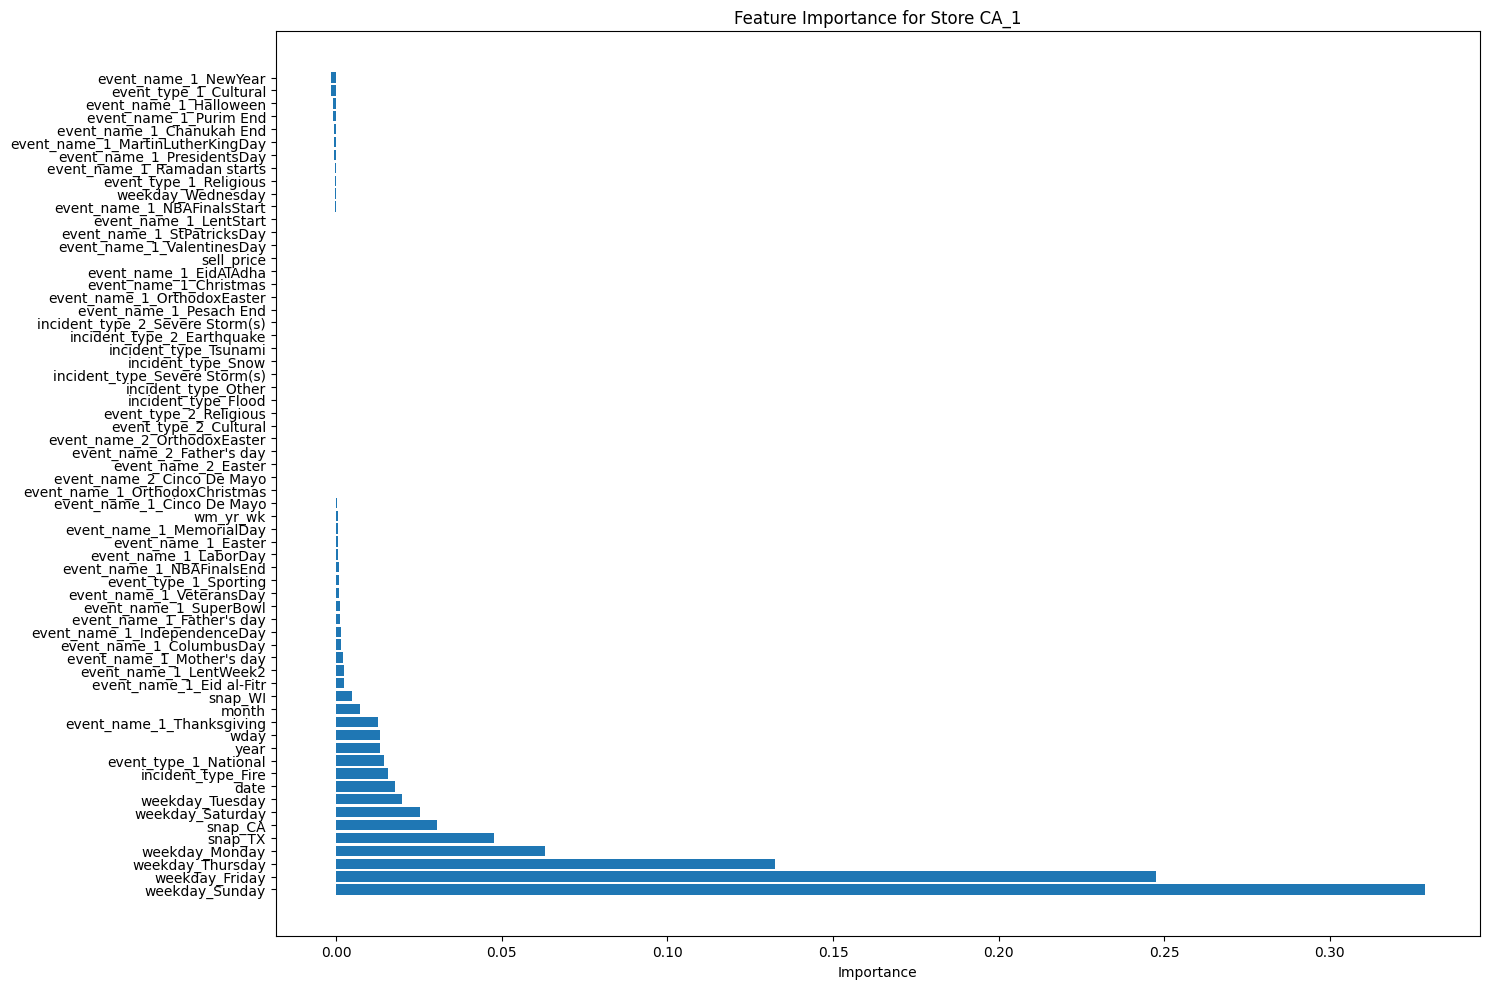

TypeError: unhashable type: 'dict'

In [ ]:
#%%

dir = "../data/df_encoded.csv"
df = pd.read_csv(dir)
store_list = df["store_id"].unique()
scaler = MinMaxScaler(feature_range=(0,1))
metrics_results = {}
features = {}
for store in store_list:
    print(f"Training begin {store}--------------------------------")
    trainX, trainY, testX, testY = prepare_data(dir, store)
    grid_search = train_model(build_model, trainX, trainY)
    my_model = grid_search.best_estimator_.model_
    
    feature_cols = [col for col in df.columns if col not in ['store_id', 'sold','count']]
    
    # Calculate and store feature importance
    feature_importance = calculate_feature_importance(store, my_model, testX, testY, feature_cols)
    
    # Store in your metrics results
    features[store] = {features: feature_importance}


    # Make predictions
    predictions = my_model.predict(testX)
    
    # Inverse transform for actual values (same as your original code)
    prediction_copies_array = np.repeat(predictions, 64, axis=-1)
    pred = scaler.inverse_transform(np.reshape(prediction_copies_array, (len(predictions), 64)))[:,0]
    
    original_copies_array = np.repeat(testY, 64, axis=-1)
    original = scaler.inverse_transform(np.reshape(original_copies_array, (len(testY), 64)))[:,0]
    
    # Calculate multiple evaluation metrics
    # 1. RMSE - Root Mean Squared Error
    rmse = np.sqrt(mean_squared_error(testY, predictions))
    
    # 2. MAE - Mean Absolute Error
    mae = mean_absolute_error(testY, predictions)
    
    # 3. MAPE - Mean Absolute Percentage Error (on original scale)
    # Avoiding division by zero
    mape = mean_absolute_percentage_error(original, pred)
    
    # 4. R² - Coefficient of Determination
    r2 = r2_score(testY, predictions)
    
    # 5. NRMSE - Normalized RMSE (as percentage of the mean)
    nrmse = rmse / np.mean(testY) * 100
    
    # 6. SMAPE - Symmetric Mean Absolute Percentage Error
    smape = 100/len(original) * np.sum(2 * np.abs(pred - original) / (np.abs(original) + np.abs(pred)))
    
    # Store all metrics
    metrics_results[store] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'SMAPE': smape,
        'R²': r2,
        'NRMSE': nrmse
    }
    
    # Print metrics
    print(f"Evaluation Metrics for Store {store}:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f} or {mape*100:.2f}%")
    print(f"SMAPE: {smape:.2f}%")
    print(f"R²: {r2:.4f}")
    print(f"NRMSE: {nrmse:.2f}%")
    
    # Plot actual vs predicted values (same as your original code)
    plt.figure(figsize=(12, 6))
    plt.plot(original, color='red', label='Real Sale Amount')
    plt.plot(pred, color='blue', label='Predicted Sale Amount')
    plt.title(f'Store Sales Prediction {store}')
    plt.xlabel('Time')
    plt.ylabel('Sales Amount')
    plt.legend()
    plt.show()
    
    print("Train Done-----------------------------------------")

# Create a comparison table of metrics across all stores
metrics_df = pd.DataFrame(metrics_results).T
print("\nMetrics Comparison Across All Stores:")
print(metrics_df)

# Plot metrics comparison
plt.figure(figsize=(15, 10))
metrics_to_plot = ['RMSE', 'MAE', 'MAPE', 'SMAPE', 'NRMSE']

for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 3, i)
    metrics_df[metric].plot(kind='bar')
    plt.title(f'{metric} Across Stores')
    plt.xticks(rotation=45)
    plt.tight_layout()

# Plot R² separately (as it has a different scale)
plt.subplot(2, 3, 6)
metrics_df['R²'].plot(kind='bar')
plt.title('R² Across Stores')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('metrics_comparison.png')
plt.show()

Training begin CA_1--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0366
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0203
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0151
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0115
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0087
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0078
Epoch 7/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0080
Epoch 8/8
47/47 [==============================] - 1s 3ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 14ms/step - loss: 0.0382
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0147
Epoch 3/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0139
Epoch 4/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0110
Epoch 5/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0088
Epoch 6/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0065
Epoch 7/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0064
Epoch 8/8
47/47 [==============================] - 1s 6ms/step


...

Epoch 1/10
38/38 [==============================] - 4s 13ms/step - loss: 0.0596
Epoch 2/10
38/38 [==============================] - 1s 19ms/step - loss: 0.0227
Epoch 3/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0194
Epoch 4/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0164
Epoch 5/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0133
Epoch 6/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0100
Epoch 7/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0089
Epoch 8/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0082
Epoch 9/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0070
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 17ms/step - loss: 0.0376
Epoch 2/10
38/38 [==============================] - 1s 20ms/step - loss: 0.0147
Epoch 3/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0132
Epoch 4/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0104
Epoch 5/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0081
Epoch 6/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0068
Epoch 7/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0060
Epoch 8/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0057
Epoch 9/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0057
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 3s 13ms/step - loss: 0.0343
Epoch 2/10
75/75 [==============================] - 1s 11ms/step - loss: 0.0175
Epoch 3/10
75/75 [==============================] - 1s 11ms/step - loss: 0.0131
Epoch 4/10
75/75 [==============================] - 1s 12ms/step - loss: 0.0090
Epoch 5/10
75/75 [==============================] - 1s 12ms/step - loss: 0.0073
Epoch 6/10
75/75 [==============================] - 1s 13ms/step - loss: 0.0066
Epoch 7/10
75/75 [==============================] - 1s 12ms/step - loss: 0.0063
Epoch 8/10
75/75 [==============================] - 1s 12ms/step - loss: 0.0059
Epoch 9/10
75/75 [==============================] - 1s 12ms/step - loss: 0.0057
Epoch 10/10
12/12 [==============================] - 0s 6ms/step

Feature Importance for Store CA_1:
weekday_Sunday: 0.3625
weekday_Friday: 0.2836
weekday_Thursday: 0.0787
weekday_Monday: 0.0522
snap_TX: 0.0448
snap_CA: 0.0277
weekday_Saturday: 0.0261
event_type_1_National: 0.021

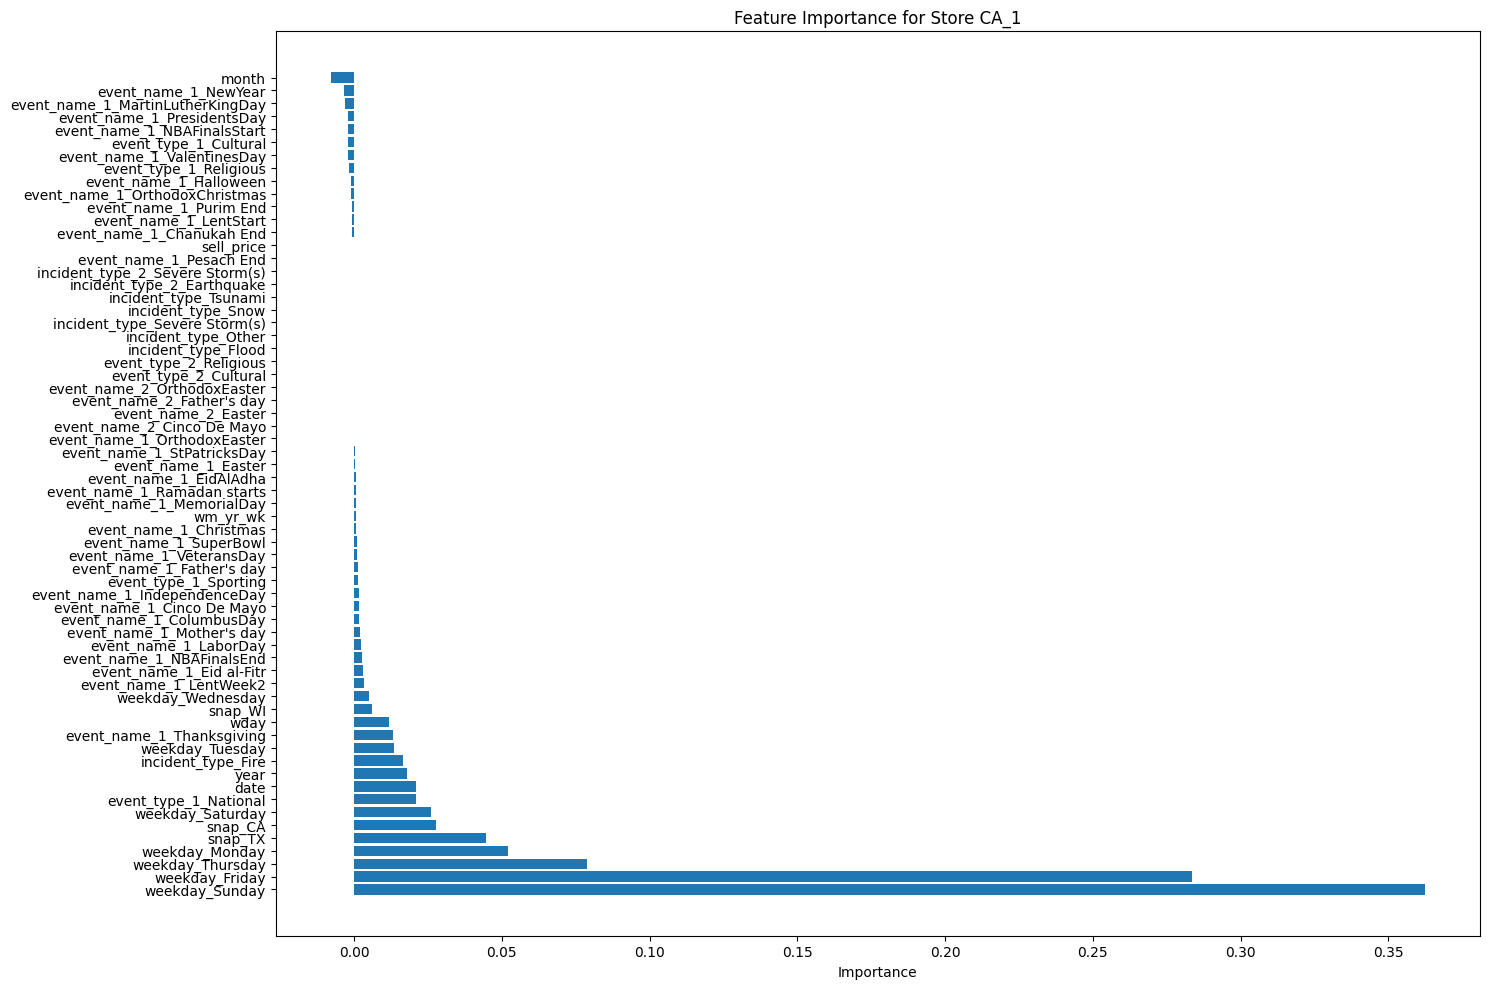

12/12 [==============================] - 0s 10ms/step
Evaluation Metrics for Store CA_1:
RMSE: 0.0721
MAE: 0.0516
MAPE: 54958020350393768.0000 or 5495802035039376384.00%
SMAPE: 8.28%
R²: 0.6947
NRMSE: 11.30%


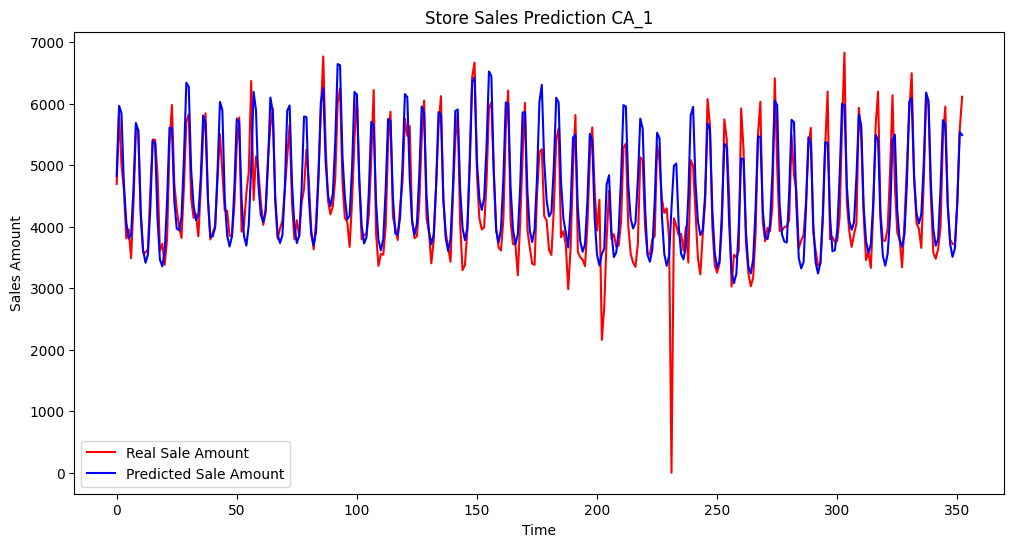

Train Done-----------------------------------------
Training begin CA_2--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 13ms/step - loss: 0.0451
Epoch 2/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0230
Epoch 3/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0183
Epoch 4/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0141
Epoch 5/8
47/47 [==============================] - 1s 16ms/step - loss: 0.0092
Epoch 6/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0085
Epoch 7/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0065
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 13ms/step - loss: 0.0437
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0184
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0152
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0128
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0088
Epoch 6/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0079
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0072
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0665
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0245
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0217
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0176
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0136
Epoch 6/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0098
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0086
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0073
Epoch 9/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0069
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0421
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0178
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0155
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0123
Epoch 5/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0093
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0075
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0065
Epoch 8/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0059
Epoch 9/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0057
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
94/94 [==============================] - 4s 12ms/step - loss: 0.0379
Epoch 2/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0181
Epoch 3/8
94/94 [==============================] - 1s 15ms/step - loss: 0.0120
Epoch 4/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0077
Epoch 5/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0068
Epoch 6/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0065
Epoch 7/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0059
Epoch 8/8
12/12 [==============================] - 0s 6ms/step

Feature Importance for Store CA_2:
weekday_Sunday: 0.2437
weekday_Friday: 0.2301
date: 0.2170
weekday_Thursday: 0.0796
wday: 0.0757
weekday_Monday: 0.0390
weekday_Saturday: 0.0301
weekday_Wednesday: 0.0212
month: 0.0204
weekday_Tuesday: 0.0188
snap_TX: 0.0154
event_name_1_Cinco De Mayo: 0.0074
sell_price: 0.0071
event_type_1_Cultural: 0.0050
event_name_1_StPatricksDay: 0.0049
wm_y

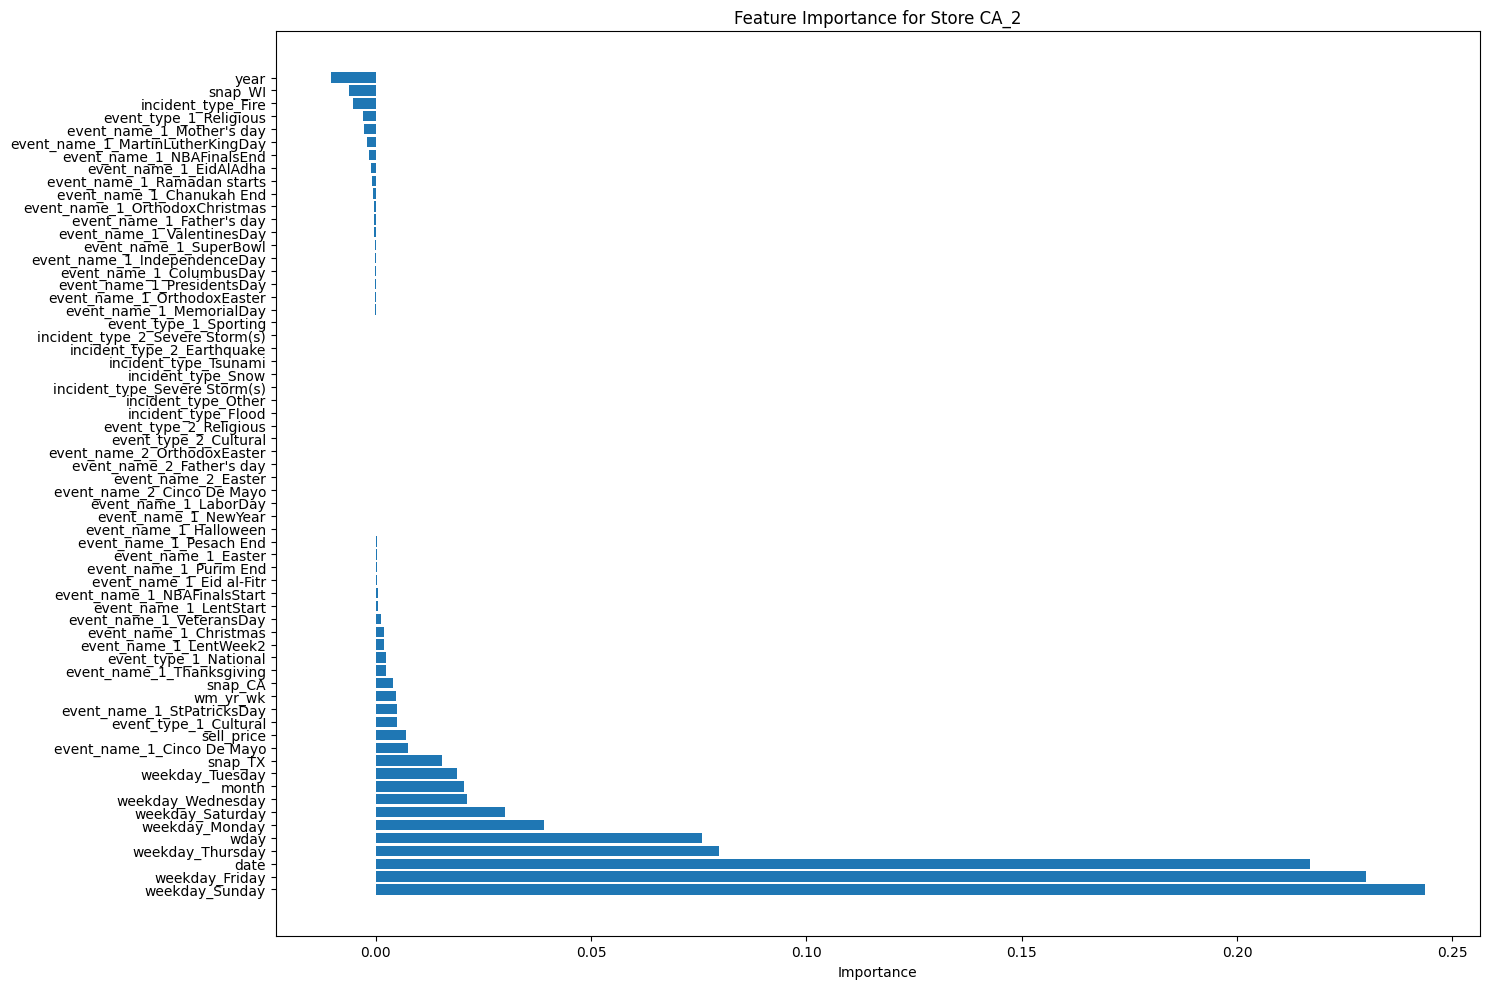

12/12 [==============================] - 0s 10ms/step
Evaluation Metrics for Store CA_2:
RMSE: 0.2073
MAE: 0.1753
MAPE: 4.4738 or 447.38%
SMAPE: 23.12%
R²: 0.1478
NRMSE: 25.49%


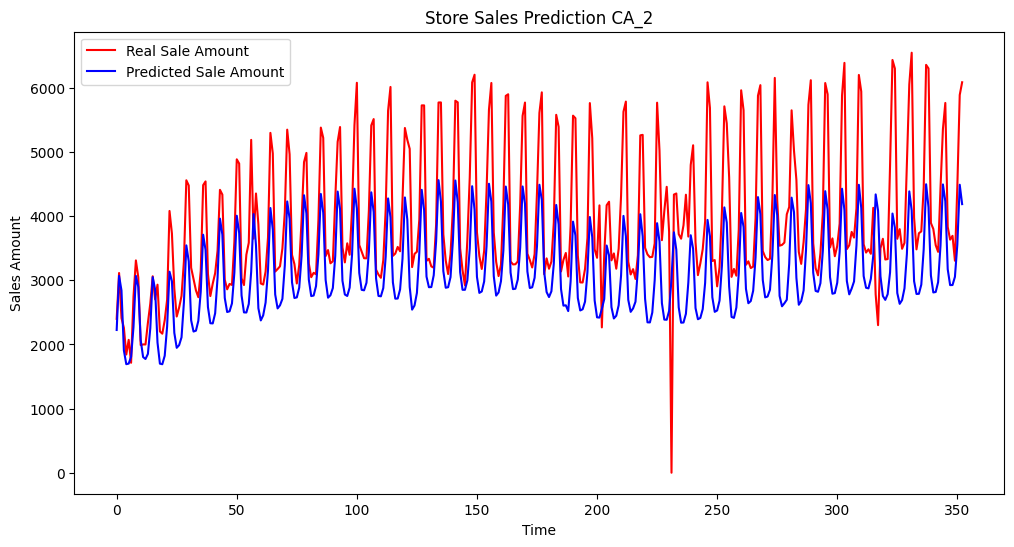

Train Done-----------------------------------------
Training begin CA_3--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 15ms/step - loss: 0.0445
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0177
Epoch 3/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0148
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0119
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0101
Epoch 6/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0086
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0074
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 14ms/step - loss: 0.0372
Epoch 2/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0119
Epoch 3/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0108
Epoch 4/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0098
Epoch 5/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0071
Epoch 6/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0068
Epoch 7/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0060
Epoch 8/8
47/47 [==============================] - 1s 6ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 14ms/step - loss: 0.0654
Epoch 2/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0188
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0149
Epoch 4/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0138
Epoch 5/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0116
Epoch 6/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0098
Epoch 7/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0087
Epoch 8/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0077
Epoch 9/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0077
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 13ms/step - loss: 0.0362
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0117
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0104
Epoch 4/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0089
Epoch 5/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0081
Epoch 6/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0075
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0065
Epoch 8/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0054
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0064
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 3s 9ms/step - loss: 0.0407
Epoch 2/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0134
Epoch 3/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0116
Epoch 4/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0096
Epoch 5/10
75/75 [==============================] - 1s 11ms/step - loss: 0.0071
Epoch 6/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0069
Epoch 7/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0065
Epoch 8/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0066
Epoch 9/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0070
Epoch 10/10
12/12 [==============================] - 0s 7ms/step

Feature Importance for Store CA_3:
weekday_Friday: 0.3013
weekday_Sunday: 0.2588
weekday_Monday: 0.0783
snap_TX: 0.0539
date: 0.0537
weekday_Saturday: 0.0519
weekday_Tuesday: 0.0433
weekday_Thursday: 0.0381
month: 0.0

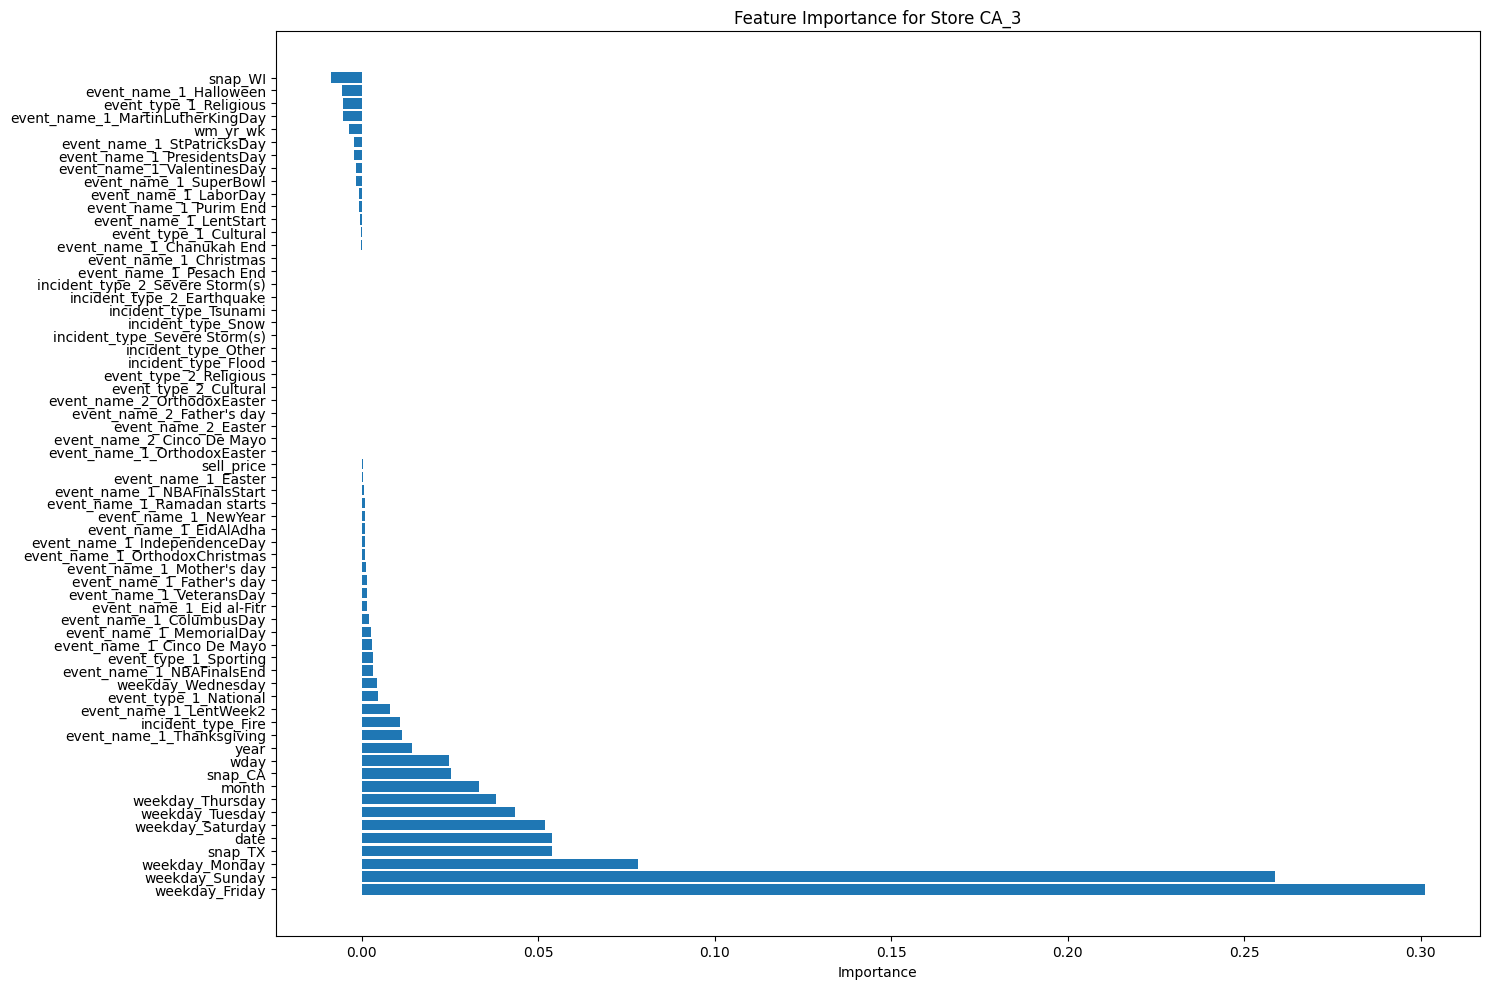

12/12 [==============================] - 0s 9ms/step
Evaluation Metrics for Store CA_3:
RMSE: 0.0670
MAE: 0.0466
MAPE: 3.7061 or 370.61%
SMAPE: 7.24%
R²: 0.6485
NRMSE: 9.95%


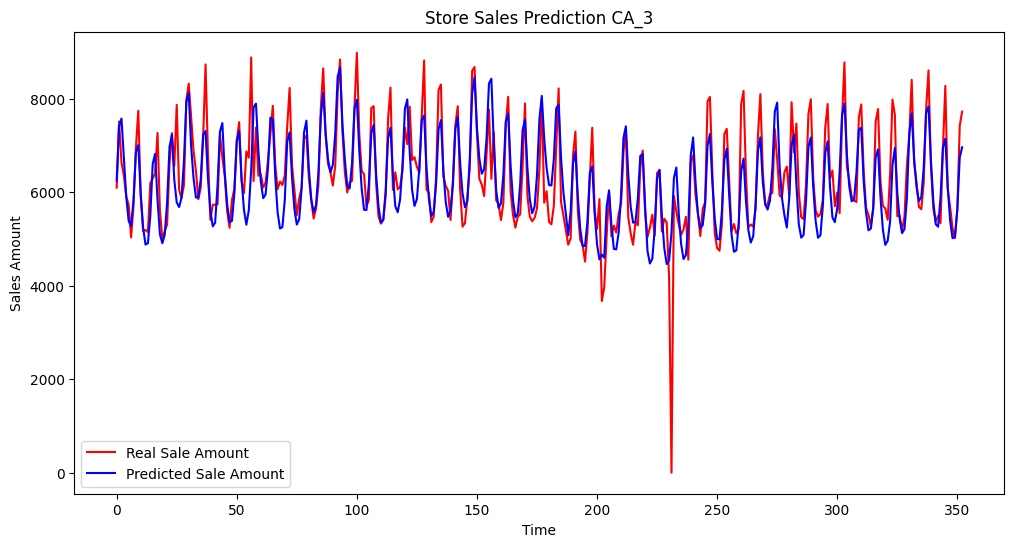

Train Done-----------------------------------------
Training begin CA_4--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 15ms/step - loss: 0.0448
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0148
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0130
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0112
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0094
Epoch 6/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0088
Epoch 7/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0085
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 12ms/step - loss: 0.0346
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0109
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0091
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0079
Epoch 5/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0072
Epoch 6/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0065
Epoch 7/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0063
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0672
Epoch 2/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0161
Epoch 3/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0132
Epoch 4/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0117
Epoch 5/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0117
Epoch 6/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0093
Epoch 7/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0094
Epoch 8/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0082
Epoch 9/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0083
Epoch 10/10
38/38 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 4s 15ms/step - loss: 0.0358
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0110
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0106
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0088
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0079
Epoch 6/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0066
Epoch 7/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0060
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0055
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0061
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
94/94 [==============================] - 4s 12ms/step - loss: 0.0310
Epoch 2/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0113
Epoch 3/8
94/94 [==============================] - 1s 13ms/step - loss: 0.0093
Epoch 4/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0076
Epoch 5/8
94/94 [==============================] - 1s 10ms/step - loss: 0.0074
Epoch 6/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0065
Epoch 7/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0065
Epoch 8/8
12/12 [==============================] - 0s 5ms/step

Feature Importance for Store CA_4:
weekday_Friday: 0.2449
weekday_Sunday: 0.2208
weekday_Monday: 0.0955
weekday_Thursday: 0.0669
date: 0.0650
snap_TX: 0.0530
year: 0.0468
weekday_Tuesday: 0.0422
incident_type_Fire: 0.0398
month: 0.0368
weekday_Saturday: 0.0254
event_type_1_National: 0.0243
event_name_1_Thanksgiving: 0.0218
snap_WI: 0.0145
snap_CA: 0.0132
wday: 0.0120
event_name_1_

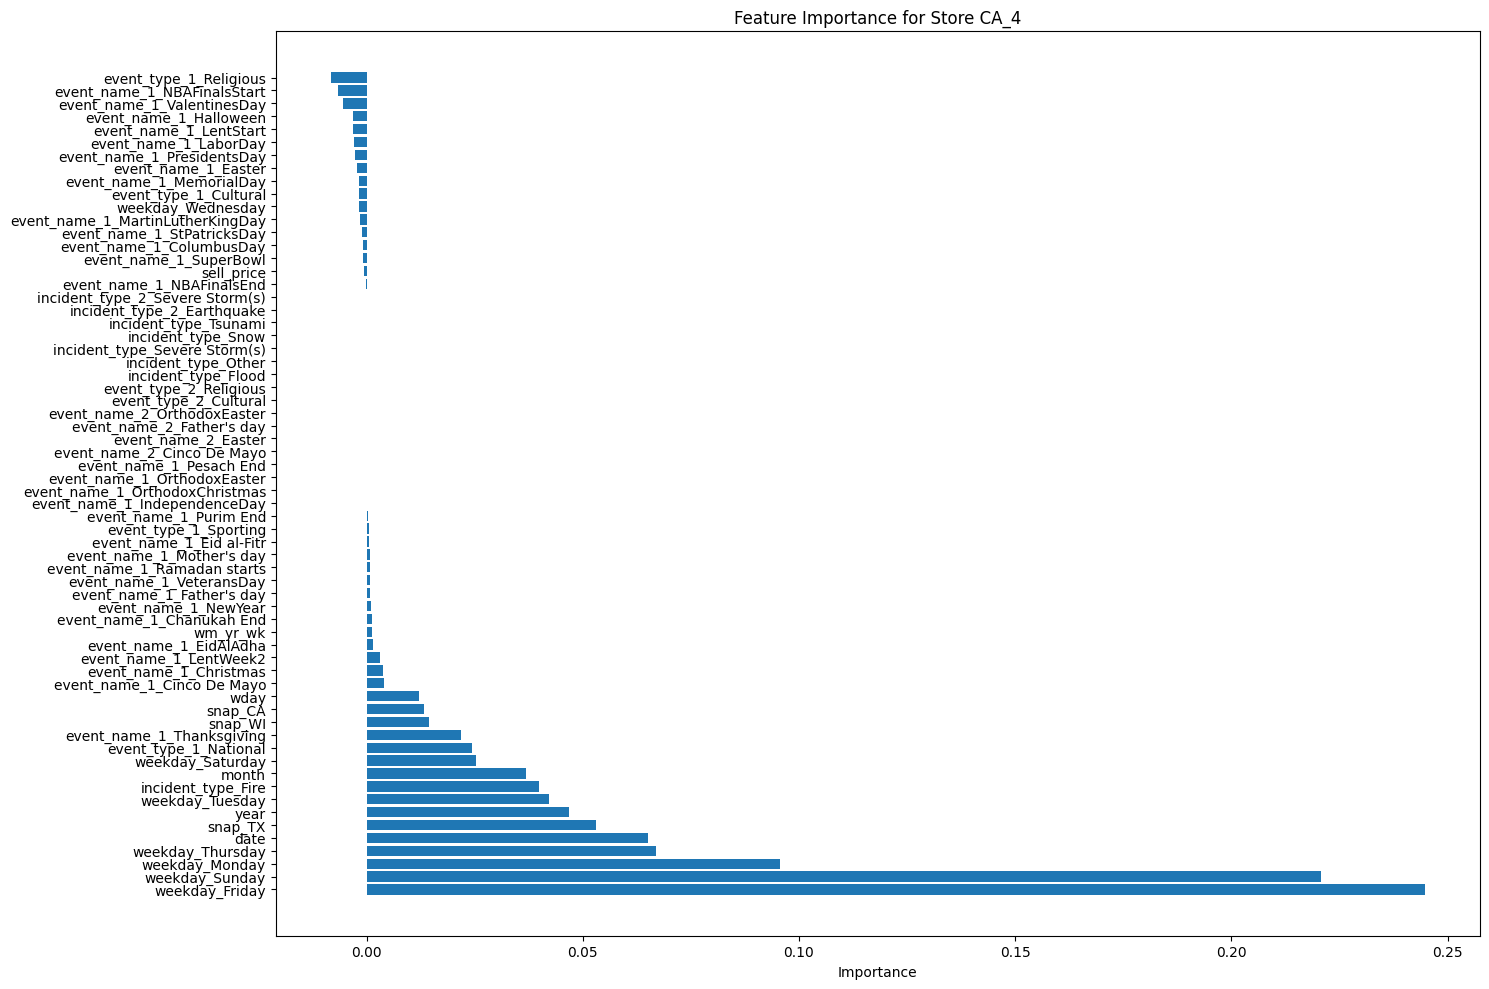

12/12 [==============================] - 0s 8ms/step
Evaluation Metrics for Store CA_4:
RMSE: 0.0738
MAE: 0.0508
MAPE: 30447903374131712.0000 or 3044790337413171200.00%
SMAPE: 7.09%
R²: 0.4220
NRMSE: 9.87%


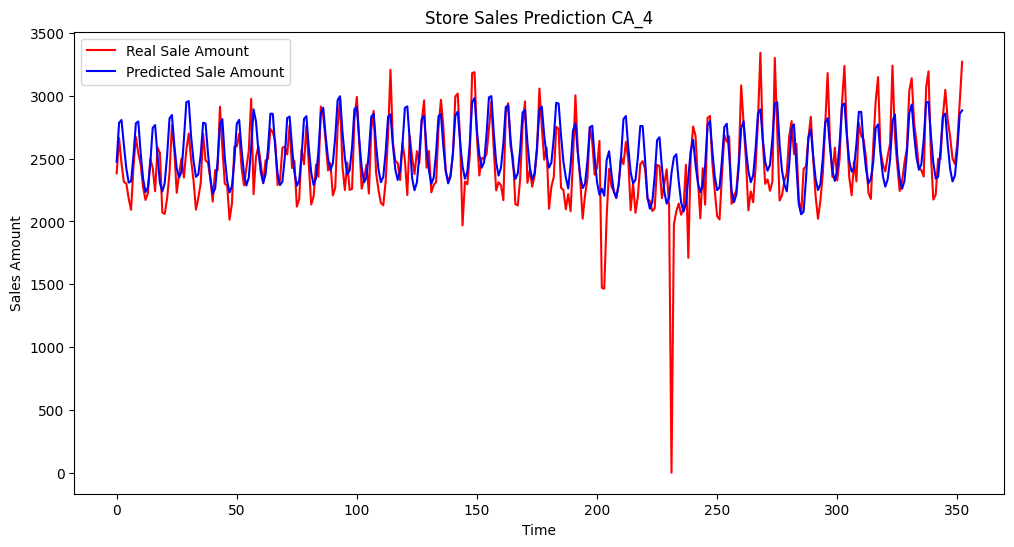

Train Done-----------------------------------------
Training begin TX_1--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 15ms/step - loss: 0.0384
Epoch 2/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0176
Epoch 3/8
47/47 [==============================] - 1s 16ms/step - loss: 0.0163
Epoch 4/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0142
Epoch 5/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0113
Epoch 6/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0094
Epoch 7/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0083
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 14ms/step - loss: 0.0394
Epoch 2/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0143
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0126
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0123
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0102
Epoch 6/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0093
Epoch 7/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0080
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 4s 12ms/step - loss: 0.0597
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0198
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0151
Epoch 4/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0147
Epoch 5/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0113
Epoch 6/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0096
Epoch 7/10
38/38 [==============================] - 1s 19ms/step - loss: 0.0085
Epoch 8/10
38/38 [==============================] - 1s 20ms/step - loss: 0.0083
Epoch 9/10
38/38 [==============================] - 1s 22ms/step - loss: 0.0080
Epoch 10/10
38/38 [==============================] - 1s 10ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 6s 24ms/step - loss: 0.0414
Epoch 2/10
38/38 [==============================] - 1s 28ms/step - loss: 0.0144
Epoch 3/10
38/38 [==============================] - 1s 29ms/step - loss: 0.0127
Epoch 4/10
38/38 [==============================] - 1s 22ms/step - loss: 0.0106
Epoch 5/10
38/38 [==============================] - 1s 22ms/step - loss: 0.0094
Epoch 6/10
38/38 [==============================] - 1s 22ms/step - loss: 0.0091
Epoch 7/10
38/38 [==============================] - 1s 28ms/step - loss: 0.0074
Epoch 8/10
38/38 [==============================] - 1s 26ms/step - loss: 0.0079
Epoch 9/10
38/38 [==============================] - 1s 24ms/step - loss: 0.0069
Epoch 10/10
38/38 [==============================] - 1s 7ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
94/94 [==============================] - 5s 17ms/step - loss: 0.0362
Epoch 2/10
94/94 [==============================] - 2s 17ms/step - loss: 0.0153
Epoch 3/10
94/94 [==============================] - 2s 16ms/step - loss: 0.0113
Epoch 4/10
94/94 [==============================] - 1s 16ms/step - loss: 0.0092
Epoch 5/10
94/94 [==============================] - 2s 17ms/step - loss: 0.0085
Epoch 6/10
94/94 [==============================] - 2s 24ms/step - loss: 0.0074
Epoch 7/10
94/94 [==============================] - 3s 28ms/step - loss: 0.0071
Epoch 8/10
94/94 [==============================] - 2s 17ms/step - loss: 0.0065
Epoch 9/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0064
Epoch 10/10
12/12 [==============================] - 0s 5ms/step

Feature Importance for Store TX_1:
weekday_Sunday: 0.4449
weekday_Friday: 0.3043
weekday_Saturday: 0.1019
date: 0.0392
snap_TX: 0.0391
weekday_Monday: 0.0358
snap_WI: 0.0290
month: 0.0268
wday: 0.0215
event_name_1_

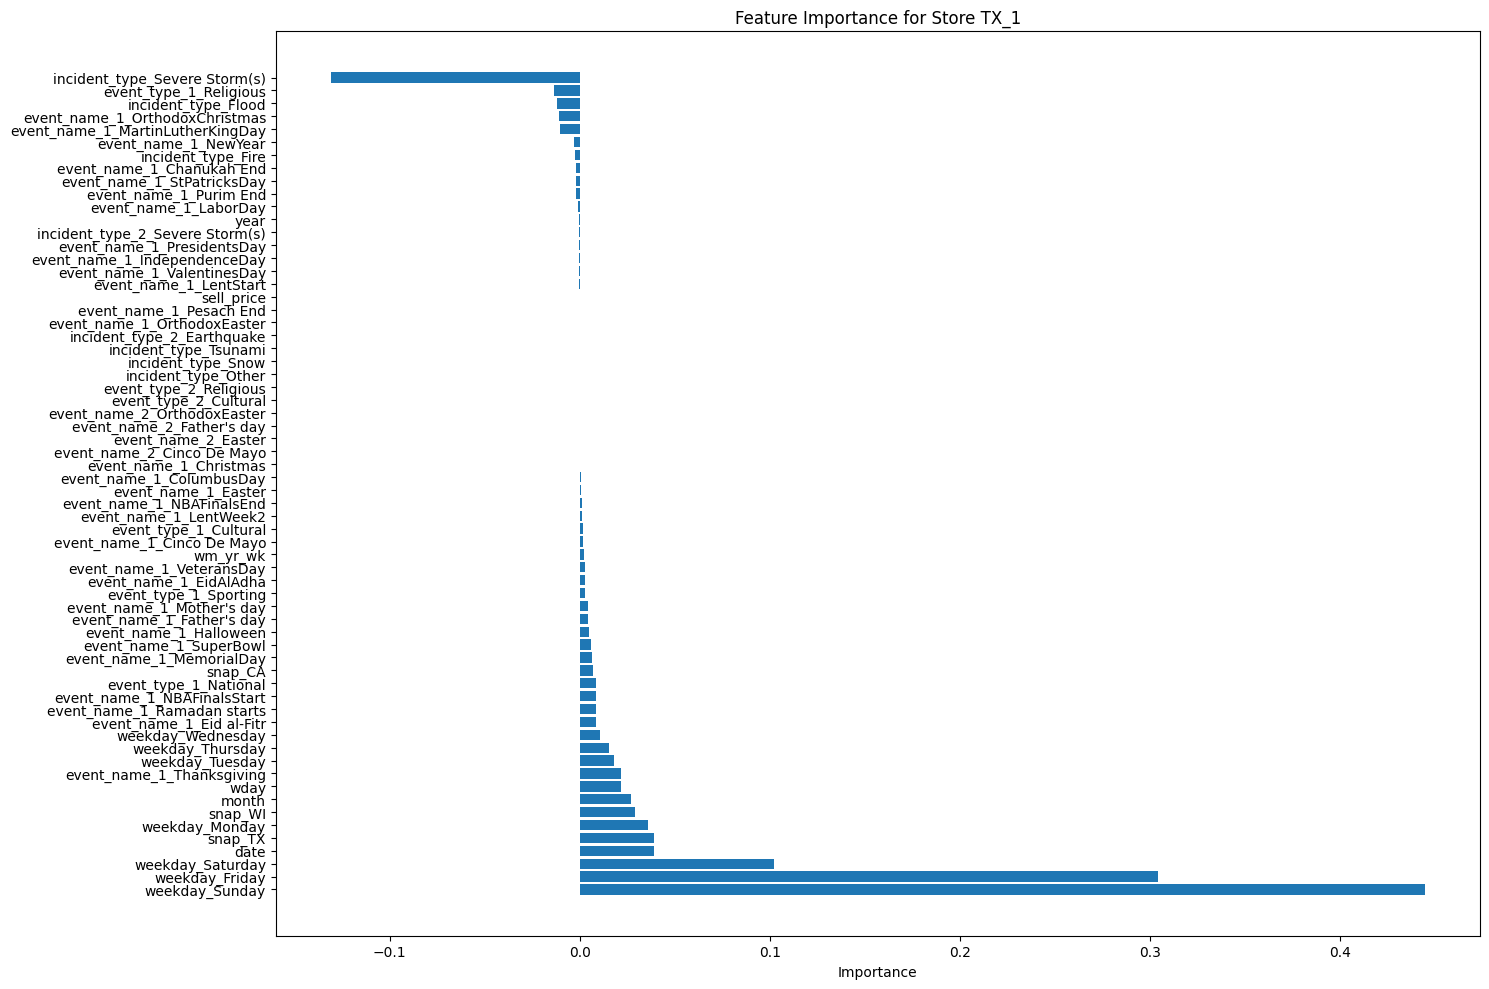

12/12 [==============================] - 0s 8ms/step
Evaluation Metrics for Store TX_1:
RMSE: 0.0824
MAE: 0.0593
MAPE: 8.1016 or 810.16%
SMAPE: 9.46%
R²: 0.5148
NRMSE: 12.27%


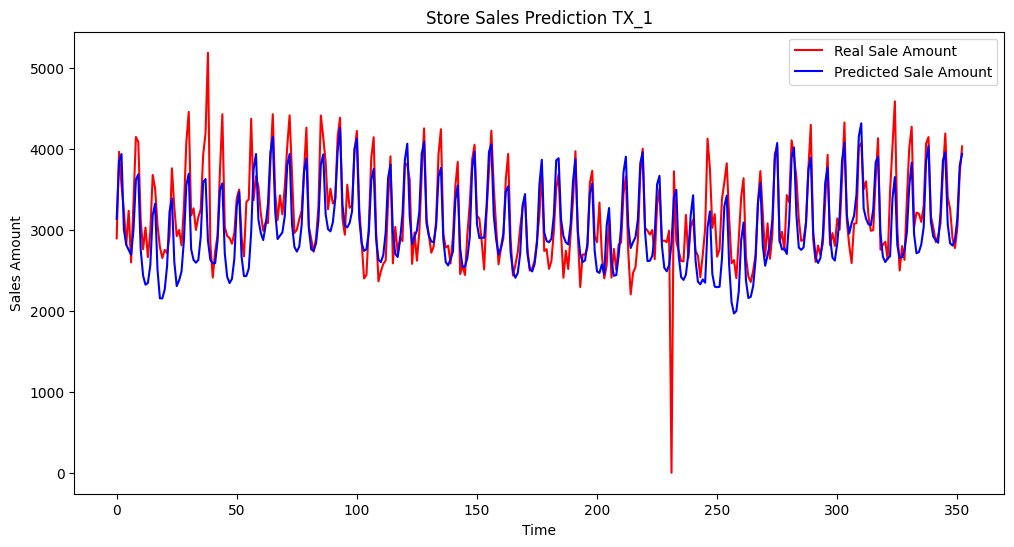

Train Done-----------------------------------------
Training begin TX_2--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 15ms/step - loss: 0.0424
Epoch 2/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0180
Epoch 3/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0166
Epoch 4/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0131
Epoch 5/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0105
Epoch 6/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0093
Epoch 7/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0080
Epoch 8/8
47/47 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 12ms/step - loss: 0.0445
Epoch 2/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0153
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0141
Epoch 4/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0128
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0108
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0100
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0075
Epoch 8/8
47/47 [==============================] - 1s 5ms/step


...

Epoch 1/10
38/38 [==============================] - 4s 17ms/step - loss: 0.0677
Epoch 2/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0223
Epoch 3/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0171
Epoch 4/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0140
Epoch 5/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0124
Epoch 6/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0099
Epoch 7/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0103
Epoch 8/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0086
Epoch 9/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0097
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 14ms/step - loss: 0.0455
Epoch 2/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0155
Epoch 3/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0134
Epoch 4/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0118
Epoch 5/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0103
Epoch 6/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0104
Epoch 7/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0081
Epoch 8/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0081
Epoch 9/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0066
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
75/75 [==============================] - 3s 12ms/step - loss: 0.0403
Epoch 2/8
75/75 [==============================] - 1s 12ms/step - loss: 0.0158
Epoch 3/8
75/75 [==============================] - 1s 12ms/step - loss: 0.0130
Epoch 4/8
75/75 [==============================] - 1s 12ms/step - loss: 0.0106
Epoch 5/8
75/75 [==============================] - 1s 12ms/step - loss: 0.0086
Epoch 6/8
75/75 [==============================] - 1s 12ms/step - loss: 0.0078
Epoch 7/8
75/75 [==============================] - 1s 12ms/step - loss: 0.0070
Epoch 8/8
12/12 [==============================] - 0s 5ms/step

Feature Importance for Store TX_2:
weekday_Sunday: 0.4138
weekday_Friday: 0.2510
weekday_Monday: 0.1171
date: 0.0799
weekday_Thursday: 0.0751
snap_TX: 0.0422
wday: 0.0366
weekday_Saturday: 0.0351
month: 0.0280
event_name_1_Thanksgiving: 0.0222
snap_CA: 0.0211
weekday_Tuesday: 0.0206
snap_WI: 0.0164
event_type_1_National: 0.0161
event_type_1_Cultural: 0.0119
event_name_1_Cinco De M

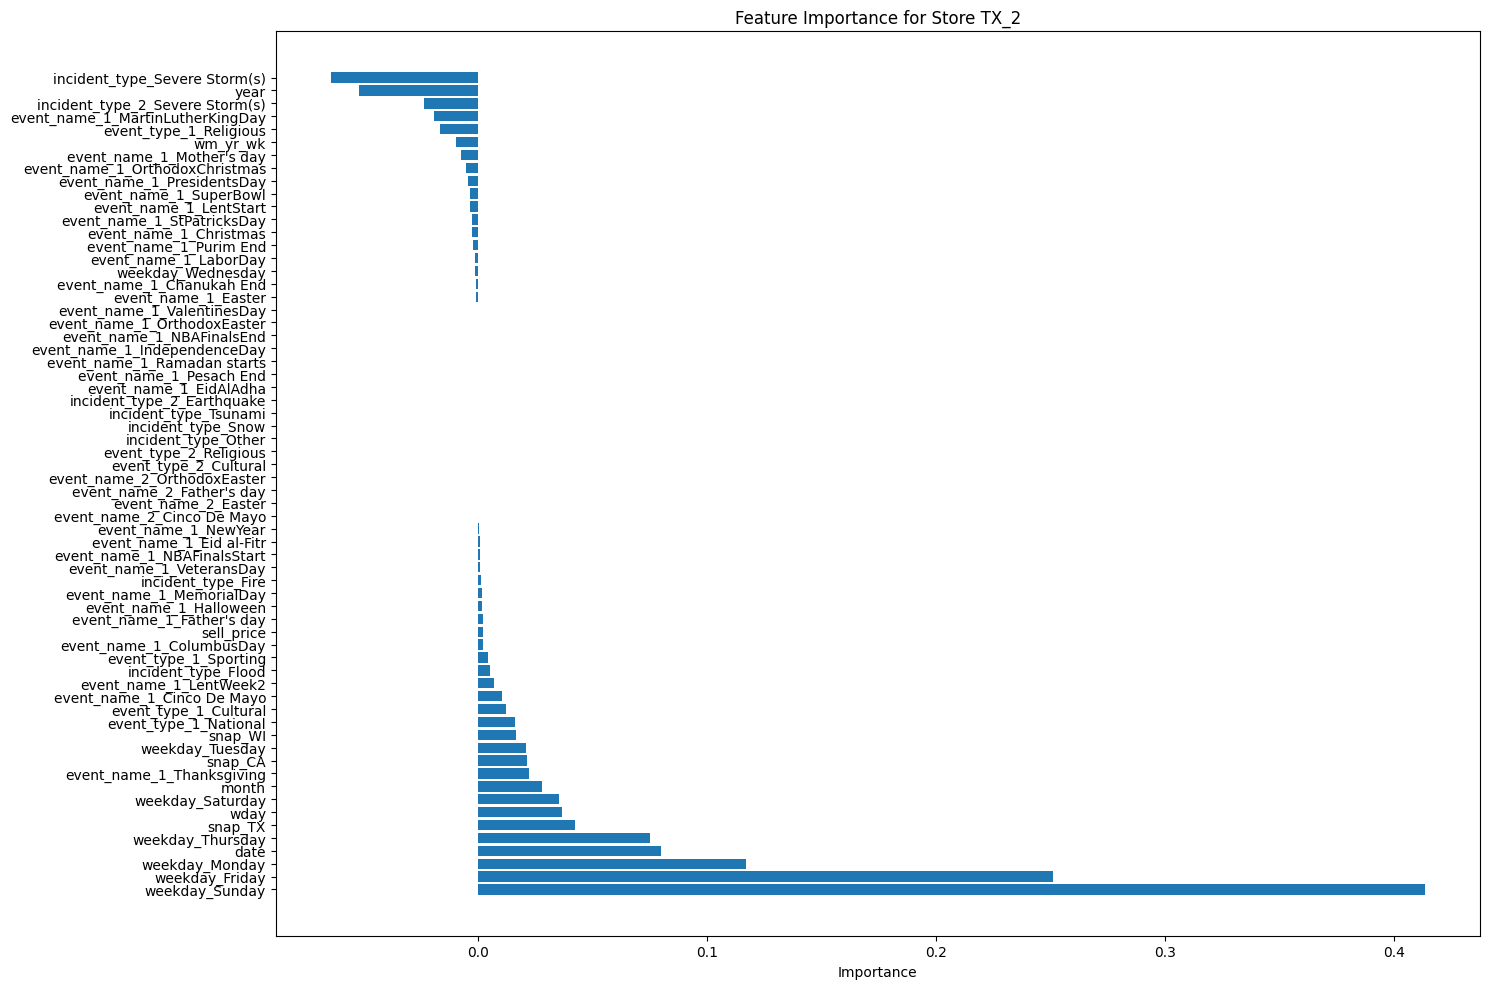

12/12 [==============================] - 0s 5ms/step
Evaluation Metrics for Store TX_2:
RMSE: 0.0824
MAE: 0.0571
MAPE: 45578479114077784.0000 or 4557847911407778304.00%
SMAPE: 9.78%
R²: 0.4150
NRMSE: 13.30%


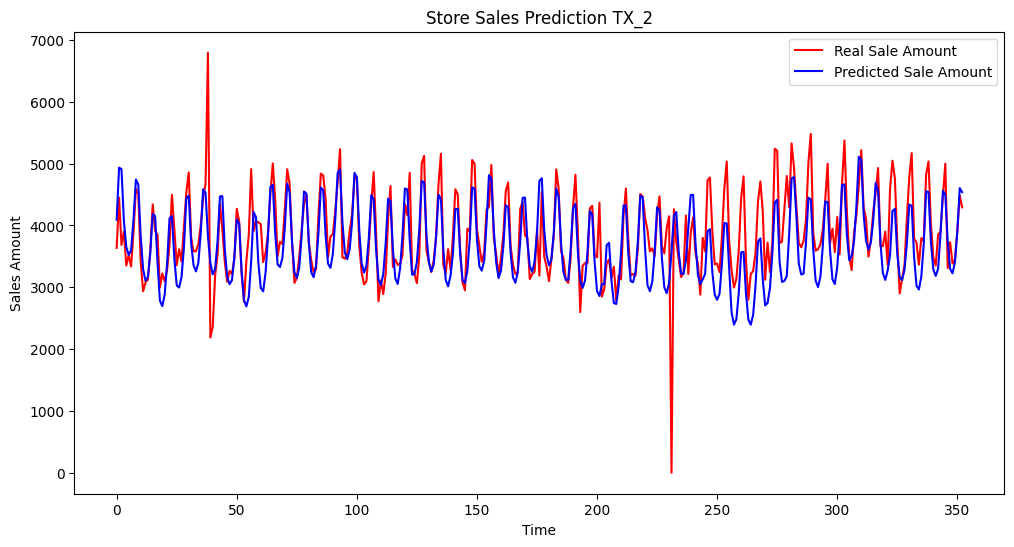

Train Done-----------------------------------------
Training begin TX_3--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 16ms/step - loss: 0.0369
Epoch 2/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0169
Epoch 3/8
47/47 [==============================] - 1s 16ms/step - loss: 0.0135
Epoch 4/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0124
Epoch 5/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0109
Epoch 6/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0095
Epoch 7/8
47/47 [==============================] - 1s 27ms/step - loss: 0.0091
Epoch 8/8
47/47 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 15ms/step - loss: 0.0374
Epoch 2/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0125
Epoch 3/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0121
Epoch 4/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0112
Epoch 5/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0089
Epoch 6/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0076
Epoch 7/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0076
Epoch 8/8
47/47 [==============================] - 1s 5ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 17ms/step - loss: 0.0635
Epoch 2/10
38/38 [==============================] - 1s 19ms/step - loss: 0.0185
Epoch 3/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0151
Epoch 4/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0136
Epoch 5/10
38/38 [==============================] - 1s 19ms/step - loss: 0.0117
Epoch 6/10
38/38 [==============================] - 1s 24ms/step - loss: 0.0106
Epoch 7/10
38/38 [==============================] - 1s 20ms/step - loss: 0.0092
Epoch 8/10
38/38 [==============================] - 1s 19ms/step - loss: 0.0083
Epoch 9/10
38/38 [==============================] - 1s 20ms/step - loss: 0.0082
Epoch 10/10
38/38 [==============================] - 1s 7ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 4s 31ms/step - loss: 0.0415
Epoch 2/10
38/38 [==============================] - 1s 30ms/step - loss: 0.0128
Epoch 3/10
38/38 [==============================] - 1s 33ms/step - loss: 0.0110
Epoch 4/10
38/38 [==============================] - 1s 31ms/step - loss: 0.0114
Epoch 5/10
38/38 [==============================] - 1s 27ms/step - loss: 0.0087
Epoch 6/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0078
Epoch 7/10
38/38 [==============================] - 1s 24ms/step - loss: 0.0077
Epoch 8/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0066
Epoch 9/10
38/38 [==============================] - 1s 23ms/step - loss: 0.0063
Epoch 10/10
38/38 [==============================] - 1s 9ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
94/94 [==============================] - 5s 20ms/step - loss: 0.0325
Epoch 2/10
94/94 [==============================] - 2s 20ms/step - loss: 0.0128
Epoch 3/10
94/94 [==============================] - 2s 19ms/step - loss: 0.0101
Epoch 4/10
94/94 [==============================] - 2s 19ms/step - loss: 0.0077
Epoch 5/10
94/94 [==============================] - 2s 20ms/step - loss: 0.0080
Epoch 6/10
94/94 [==============================] - 2s 17ms/step - loss: 0.0071
Epoch 7/10
94/94 [==============================] - 2s 20ms/step - loss: 0.0064
Epoch 8/10
94/94 [==============================] - 2s 19ms/step - loss: 0.0067
Epoch 9/10
94/94 [==============================] - 2s 18ms/step - loss: 0.0063
Epoch 10/10
12/12 [==============================] - 0s 13ms/step

Feature Importance for Store TX_3:
weekday_Sunday: 0.3032
weekday_Friday: 0.2479
weekday_Monday: 0.0868
snap_WI: 0.0861
month: 0.0527
weekday_Thursday: 0.0479
snap_TX: 0.0383
event_name_1_Thanksgiving: 0.0354
snap

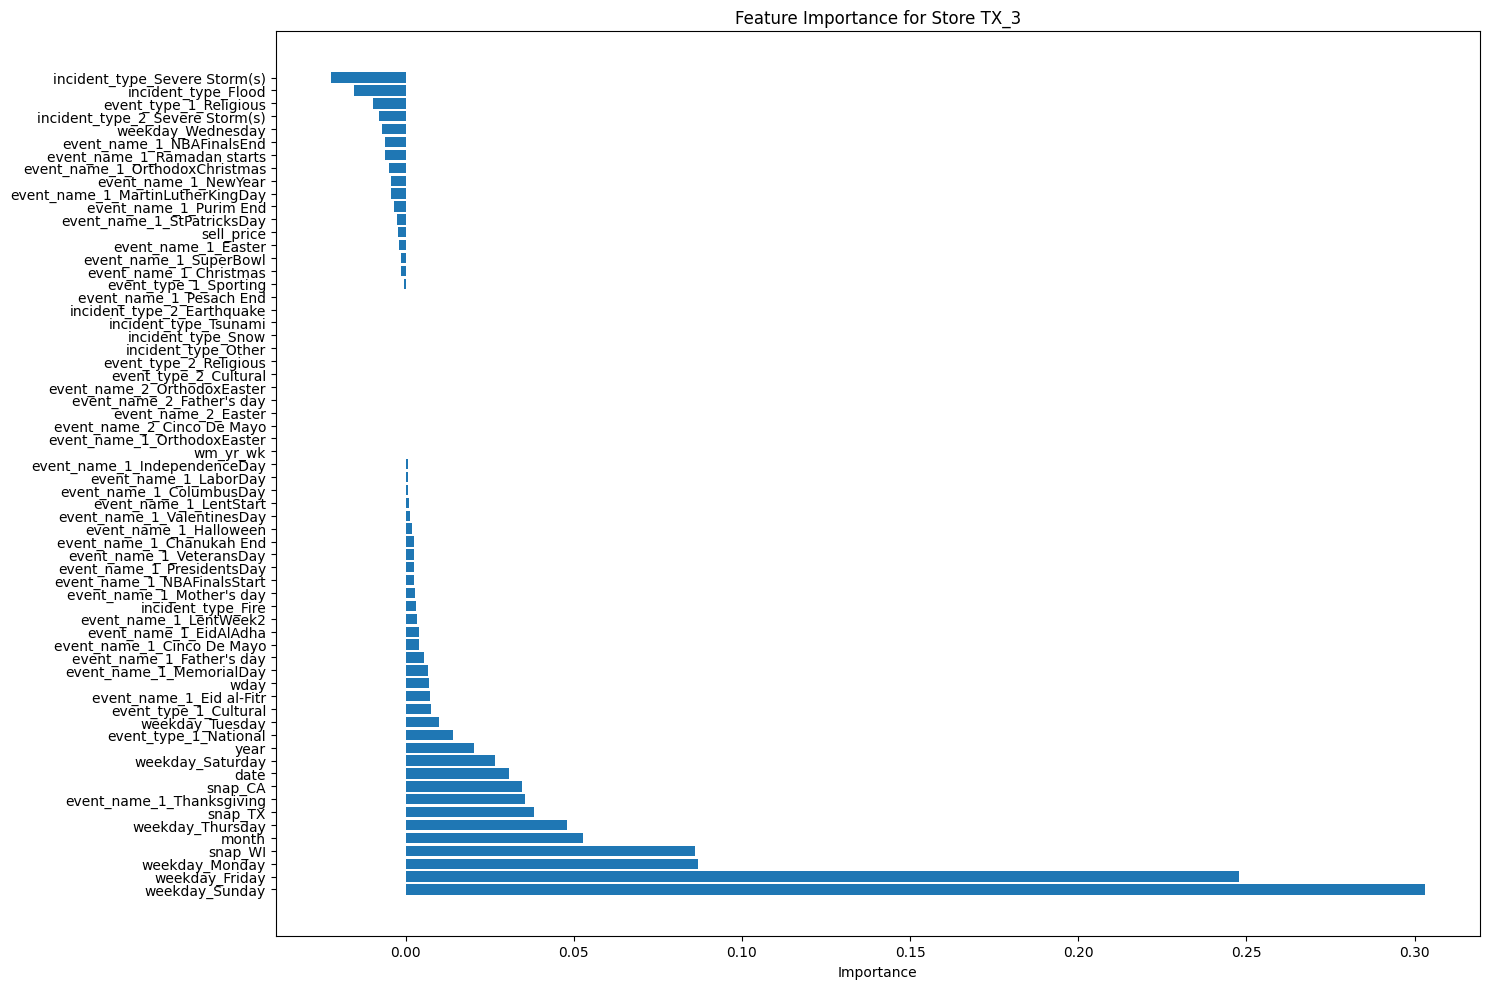

12/12 [==============================] - 0s 8ms/step
Evaluation Metrics for Store TX_3:
RMSE: 0.0855
MAE: 0.0583
MAPE: 3.3650 or 336.50%
SMAPE: 8.12%
R²: 0.4703
NRMSE: 11.34%


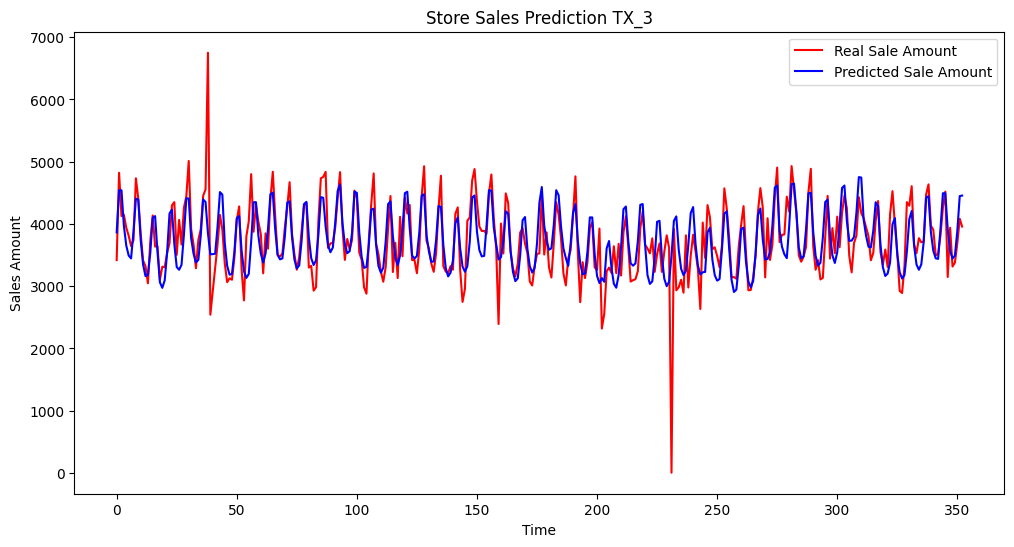

Train Done-----------------------------------------
Training begin WI_1--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 16ms/step - loss: 0.0230
Epoch 2/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0121
Epoch 3/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0093
Epoch 4/8
47/47 [==============================] - 1s 19ms/step - loss: 0.0073
Epoch 5/8
47/47 [==============================] - 1s 16ms/step - loss: 0.0055
Epoch 6/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0053
Epoch 7/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0053
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 14ms/step - loss: 0.0140
Epoch 2/8
47/47 [==============================] - 1s 16ms/step - loss: 0.0065
Epoch 3/8
47/47 [==============================] - 1s 16ms/step - loss: 0.0055
Epoch 4/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0045
Epoch 5/8
47/47 [==============================] - 1s 16ms/step - loss: 0.0042
Epoch 6/8
47/47 [==============================] - 1s 17ms/step - loss: 0.0039
Epoch 7/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0043
Epoch 8/8
47/47 [==============================] - 1s 5ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 16ms/step - loss: 0.0396
Epoch 2/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0140
Epoch 3/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0109
Epoch 4/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0098
Epoch 5/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0077
Epoch 6/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0061
Epoch 7/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0060
Epoch 8/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0056
Epoch 9/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0056
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 16ms/step - loss: 0.0124
Epoch 2/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0055
Epoch 3/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0047
Epoch 4/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0044
Epoch 5/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0036
Epoch 6/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0034
Epoch 7/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0032
Epoch 8/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0031
Epoch 9/10
38/38 [==============================] - 1s 18ms/step - loss: 0.0029
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
75/75 [==============================] - 4s 16ms/step - loss: 0.0184
Epoch 2/8
75/75 [==============================] - 1s 15ms/step - loss: 0.0090
Epoch 3/8
75/75 [==============================] - 1s 16ms/step - loss: 0.0074
Epoch 4/8
75/75 [==============================] - 1s 15ms/step - loss: 0.0052
Epoch 5/8
75/75 [==============================] - 1s 15ms/step - loss: 0.0046
Epoch 6/8
75/75 [==============================] - 1s 15ms/step - loss: 0.0042
Epoch 7/8
75/75 [==============================] - 1s 16ms/step - loss: 0.0041
Epoch 8/8
12/12 [==============================] - 0s 8ms/step

Feature Importance for Store WI_1:
weekday_Sunday: 0.2527
weekday_Friday: 0.2114
weekday_Saturday: 0.1414
weekday_Thursday: 0.1393
snap_TX: 0.0765
wday: 0.0765
weekday_Monday: 0.0309
year: 0.0288
month: 0.0141
weekday_Tuesday: 0.0097
event_name_1_Thanksgiving: 0.0083
weekday_Wednesday: 0.0076
event_type_1_National: 0.0071
event_name_1_LentStart: 0.0036
snap_WI: 0.0025
event_name_1

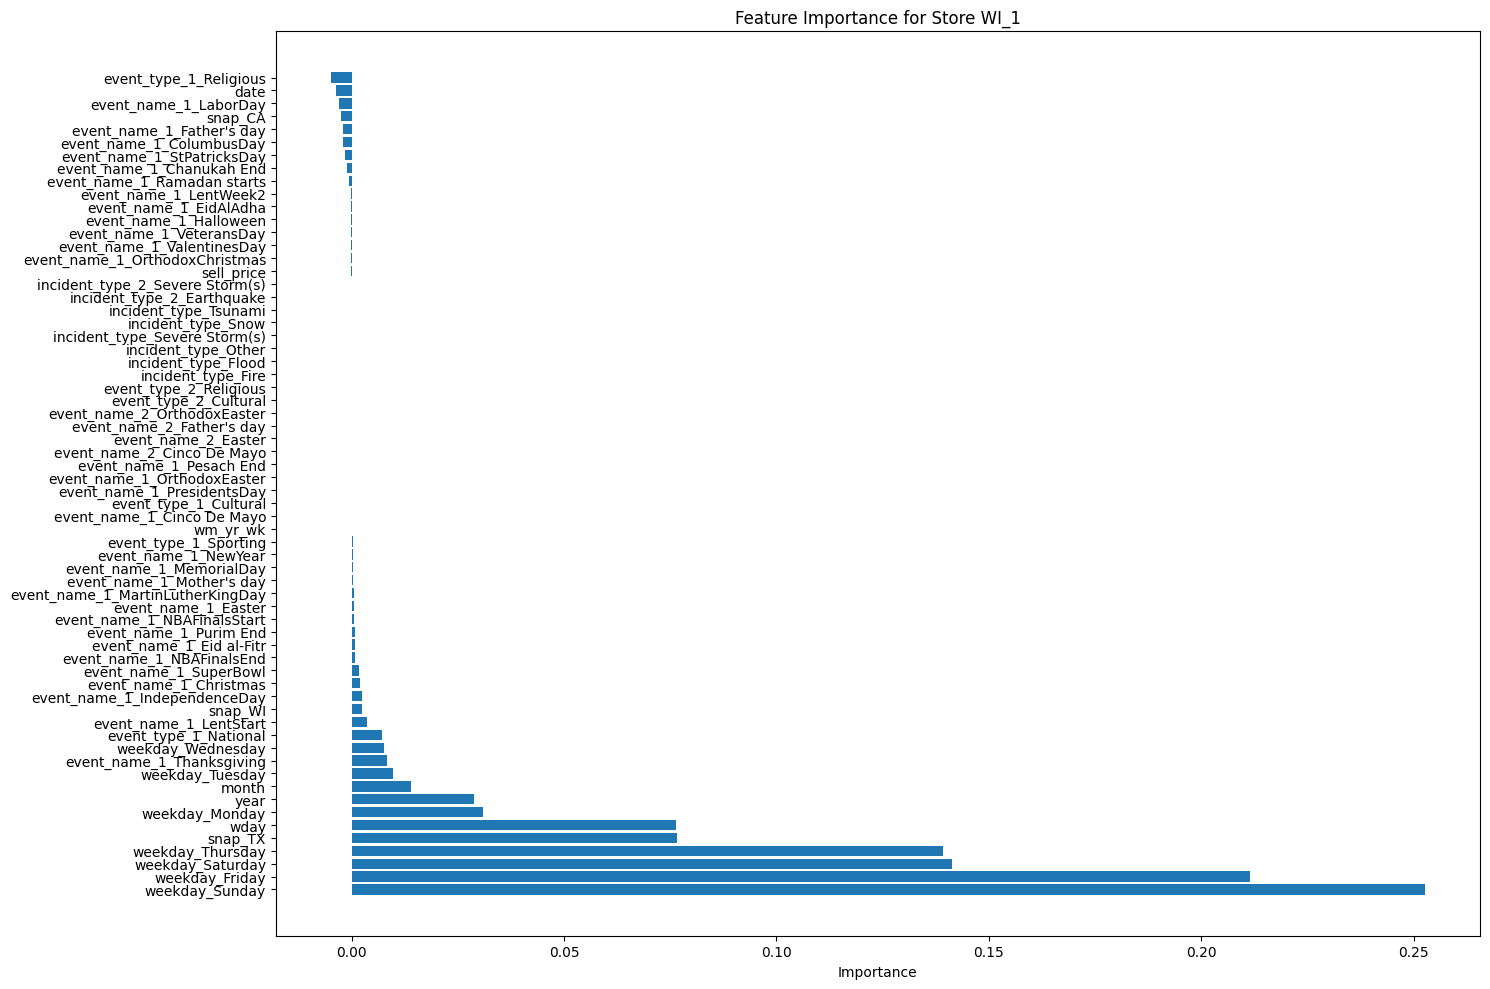

12/12 [==============================] - 0s 12ms/step
Evaluation Metrics for Store WI_1:
RMSE: 0.0746
MAE: 0.0542
MAPE: 5.2747 or 527.47%
SMAPE: 10.87%
R²: 0.5900
NRMSE: 14.31%


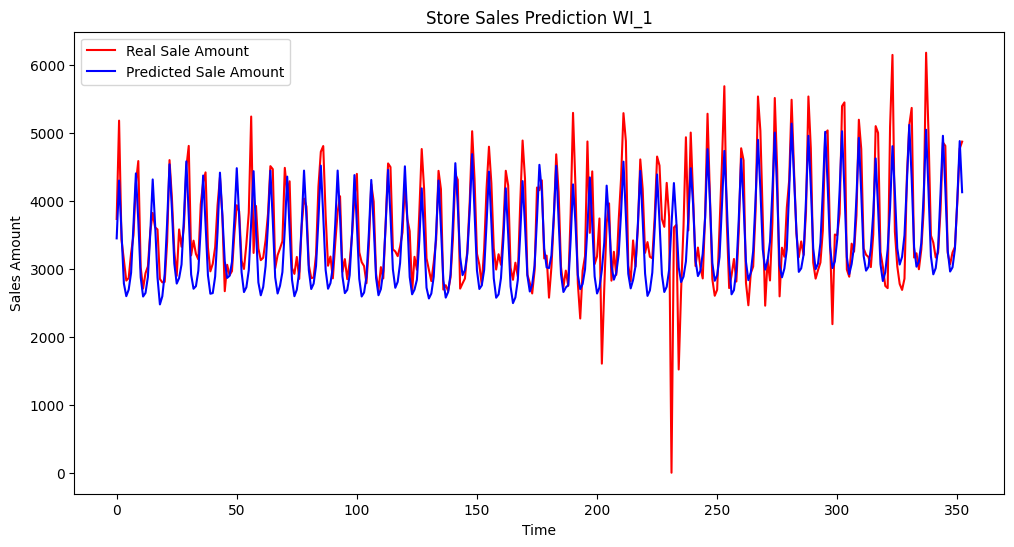

Train Done-----------------------------------------
Training begin WI_2--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 22ms/step - loss: 0.0361
Epoch 2/8
47/47 [==============================] - 1s 20ms/step - loss: 0.0186
Epoch 3/8
47/47 [==============================] - 1s 22ms/step - loss: 0.0162
Epoch 4/8
47/47 [==============================] - 1s 20ms/step - loss: 0.0155
Epoch 5/8
47/47 [==============================] - 1s 18ms/step - loss: 0.0138
Epoch 6/8
47/47 [==============================] - 1s 19ms/step - loss: 0.0121
Epoch 7/8
47/47 [==============================] - 1s 22ms/step - loss: 0.0131
Epoch 8/8
47/47 [==============================] - 1s 8ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 20ms/step - loss: 0.0240
Epoch 2/8
47/47 [==============================] - 1s 21ms/step - loss: 0.0108
Epoch 3/8
47/47 [==============================] - 1s 22ms/step - loss: 0.0094
Epoch 4/8
47/47 [==============================] - 1s 19ms/step - loss: 0.0081
Epoch 5/8
47/47 [==============================] - 1s 20ms/step - loss: 0.0073
Epoch 6/8
47/47 [==============================] - 1s 20ms/step - loss: 0.0070
Epoch 7/8
47/47 [==============================] - 1s 20ms/step - loss: 0.0062
Epoch 8/8
47/47 [==============================] - 1s 7ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 18ms/step - loss: 0.0670
Epoch 2/10
38/38 [==============================] - 1s 20ms/step - loss: 0.0184
Epoch 3/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0169
Epoch 4/10
38/38 [==============================] - 1s 19ms/step - loss: 0.0159
Epoch 5/10
38/38 [==============================] - 1s 20ms/step - loss: 0.0147
Epoch 6/10
38/38 [==============================] - 1s 19ms/step - loss: 0.0144
Epoch 7/10
38/38 [==============================] - 1s 23ms/step - loss: 0.0126
Epoch 8/10
38/38 [==============================] - 1s 24ms/step - loss: 0.0114
Epoch 9/10
38/38 [==============================] - 1s 23ms/step - loss: 0.0116
Epoch 10/10
38/38 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 4s 22ms/step - loss: 0.0278
Epoch 2/10
38/38 [==============================] - 1s 20ms/step - loss: 0.0091
Epoch 3/10
38/38 [==============================] - 1s 22ms/step - loss: 0.0087
Epoch 4/10
38/38 [==============================] - 1s 23ms/step - loss: 0.0080
Epoch 5/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0079
Epoch 6/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0067
Epoch 7/10
38/38 [==============================] - 1s 19ms/step - loss: 0.0064
Epoch 8/10
38/38 [==============================] - 1s 19ms/step - loss: 0.0063
Epoch 9/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0060
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 4s 17ms/step - loss: 0.0330
Epoch 2/10
75/75 [==============================] - 1s 18ms/step - loss: 0.0156
Epoch 3/10
75/75 [==============================] - 2s 20ms/step - loss: 0.0139
Epoch 4/10
75/75 [==============================] - 1s 18ms/step - loss: 0.0112
Epoch 5/10
75/75 [==============================] - 2s 22ms/step - loss: 0.0111
Epoch 6/10
75/75 [==============================] - 2s 24ms/step - loss: 0.0097
Epoch 7/10
75/75 [==============================] - 2s 21ms/step - loss: 0.0087
Epoch 8/10
75/75 [==============================] - 1s 18ms/step - loss: 0.0084
Epoch 9/10
75/75 [==============================] - 2s 20ms/step - loss: 0.0081
Epoch 10/10
12/12 [==============================] - 0s 7ms/step

Feature Importance for Store WI_2:
date: 0.2619
snap_TX: 0.2175
snap_WI: 0.1553
snap_CA: 0.1404
weekday_Saturday: 0.0446
weekday_Sunday: 0.0434
weekday_Thursday: 0.0392
weekday_Friday: 0.0220
year: 0.0199
weekday_T

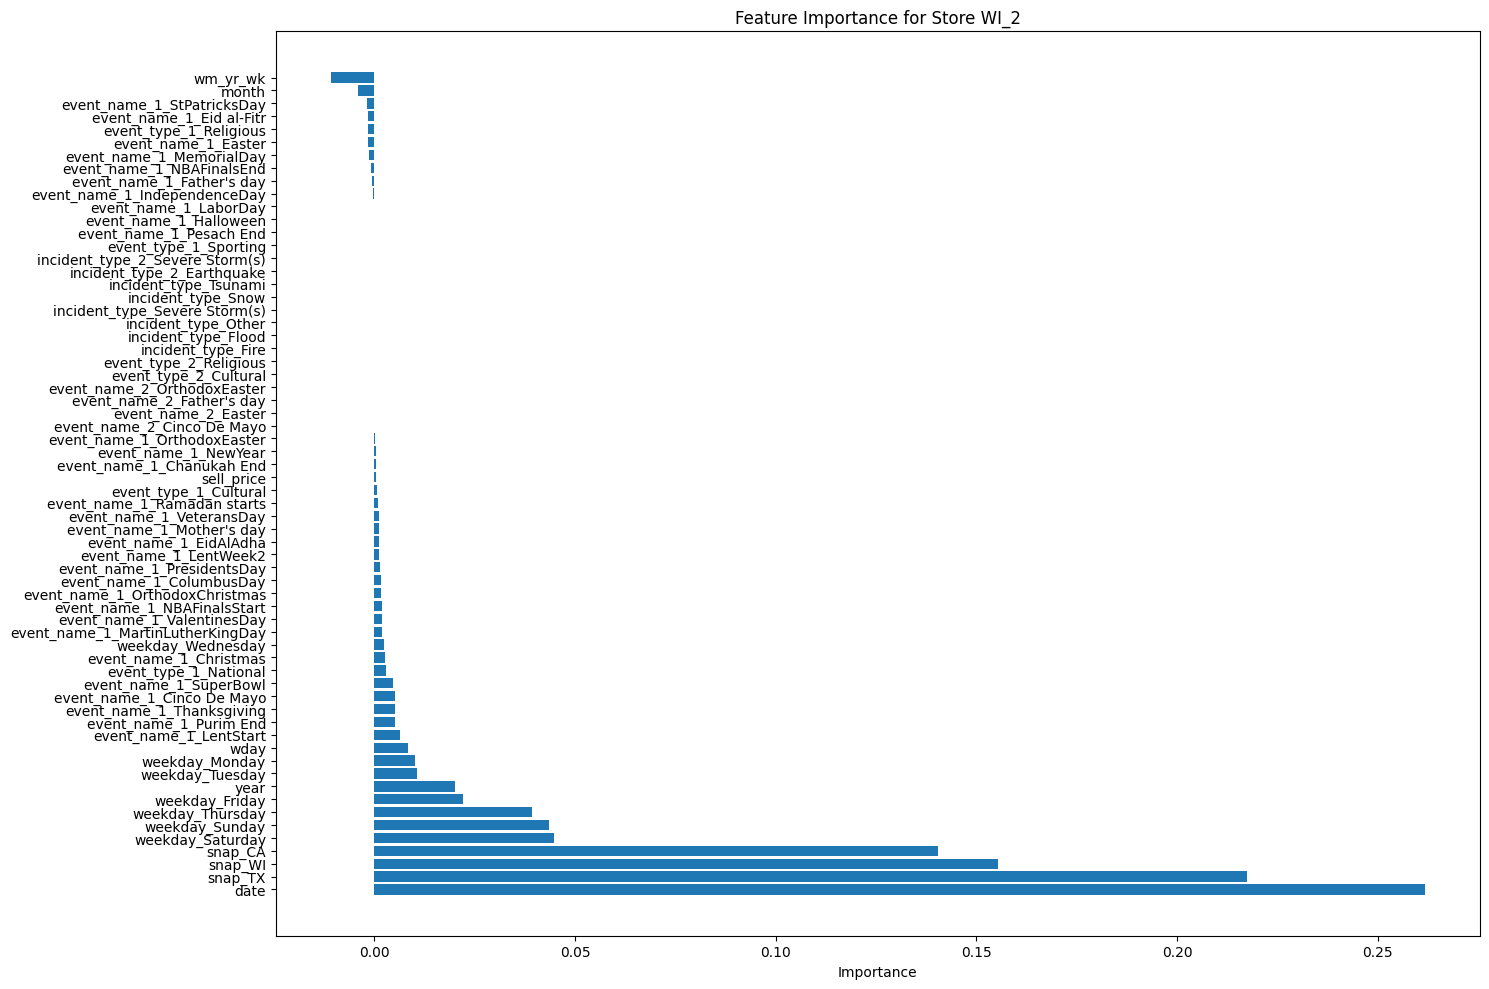

12/12 [==============================] - 0s 9ms/step
Evaluation Metrics for Store WI_2:
RMSE: 0.1050
MAE: 0.0781
MAPE: 10.6695 or 1066.95%
SMAPE: 11.04%
R²: 0.5774
NRMSE: 14.43%


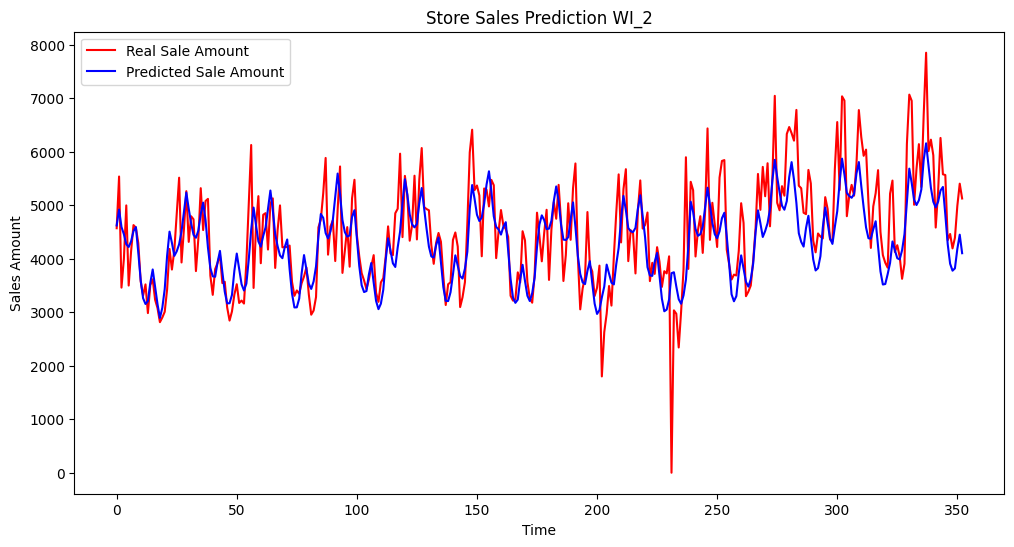

Train Done-----------------------------------------
Training begin WI_3--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 24ms/step - loss: 0.0235
Epoch 2/8
47/47 [==============================] - 1s 22ms/step - loss: 0.0129
Epoch 3/8
47/47 [==============================] - 1s 21ms/step - loss: 0.0110
Epoch 4/8
47/47 [==============================] - 1s 20ms/step - loss: 0.0091
Epoch 5/8
47/47 [==============================] - 1s 19ms/step - loss: 0.0072
Epoch 6/8
47/47 [==============================] - 1s 19ms/step - loss: 0.0059
Epoch 7/8
47/47 [==============================] - 1s 20ms/step - loss: 0.0060
Epoch 8/8
47/47 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 20ms/step - loss: 0.0442
Epoch 2/8
47/47 [==============================] - 1s 19ms/step - loss: 0.0177
Epoch 3/8
47/47 [==============================] - 1s 19ms/step - loss: 0.0167
Epoch 4/8
47/47 [==============================] - 1s 20ms/step - loss: 0.0154
Epoch 5/8
47/47 [==============================] - 1s 19ms/step - loss: 0.0137
Epoch 6/8
47/47 [==============================] - 1s 21ms/step - loss: 0.0118
Epoch 7/8
47/47 [==============================] - 1s 19ms/step - loss: 0.0109
Epoch 8/8
47/47 [==============================] - 1s 6ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 23ms/step - loss: 0.0432
Epoch 2/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0129
Epoch 3/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0109
Epoch 4/10
38/38 [==============================] - 1s 22ms/step - loss: 0.0089
Epoch 5/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0079
Epoch 6/10
38/38 [==============================] - 1s 20ms/step - loss: 0.0071
Epoch 7/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0066
Epoch 8/10
38/38 [==============================] - 1s 22ms/step - loss: 0.0064
Epoch 9/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0059
Epoch 10/10
38/38 [==============================] - 1s 7ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 21ms/step - loss: 0.0551
Epoch 2/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0189
Epoch 3/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0159
Epoch 4/10
38/38 [==============================] - 1s 20ms/step - loss: 0.0151
Epoch 5/10
38/38 [==============================] - 1s 23ms/step - loss: 0.0130
Epoch 6/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0109
Epoch 7/10
38/38 [==============================] - 1s 20ms/step - loss: 0.0106
Epoch 8/10
38/38 [==============================] - 1s 22ms/step - loss: 0.0098
Epoch 9/10
38/38 [==============================] - 1s 21ms/step - loss: 0.0093
Epoch 10/10
38/38 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
94/94 [==============================] - 4s 21ms/step - loss: 0.0319
Epoch 2/8
94/94 [==============================] - 2s 21ms/step - loss: 0.0146
Epoch 3/8
94/94 [==============================] - 2s 21ms/step - loss: 0.0115
Epoch 4/8
94/94 [==============================] - 2s 21ms/step - loss: 0.0105
Epoch 5/8
94/94 [==============================] - 2s 22ms/step - loss: 0.0086
Epoch 6/8
94/94 [==============================] - 2s 21ms/step - loss: 0.0082
Epoch 7/8
94/94 [==============================] - 2s 22ms/step - loss: 0.0074
Epoch 8/8
12/12 [==============================] - 0s 9ms/step

Feature Importance for Store WI_3:
snap_TX: 0.2600
weekday_Sunday: 0.1419
date: 0.1269
snap_WI: 0.1141
weekday_Thursday: 0.0917
weekday_Saturday: 0.0606
weekday_Friday: 0.0535
snap_CA: 0.0518
wday: 0.0429
month: 0.0366
weekday_Monday: 0.0319
weekday_Tuesday: 0.0277
weekday_Wednesday: 0.0040
event_name_1_Thanksgiving: 0.0036
event_name_1_SuperBowl: 0.0032
event_name_1_Ramadan start

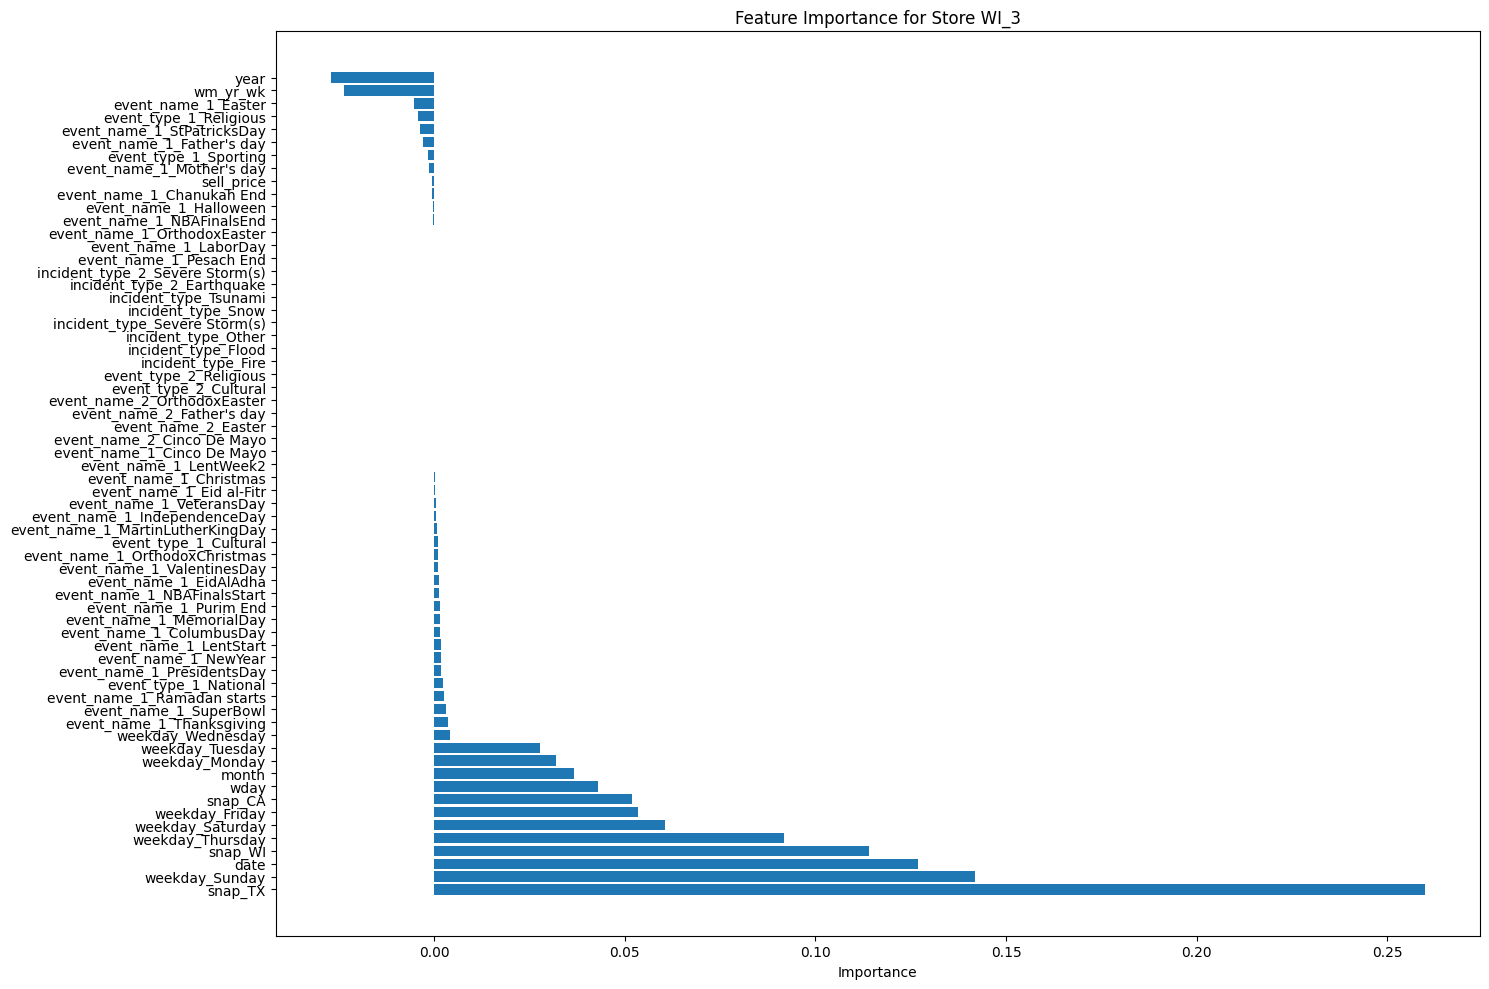

12/12 [==============================] - 0s 17ms/step
Evaluation Metrics for Store WI_3:
RMSE: 0.0906
MAE: 0.0670
MAPE: 9.0154 or 901.54%
SMAPE: 11.72%
R²: 0.4550
NRMSE: 15.58%


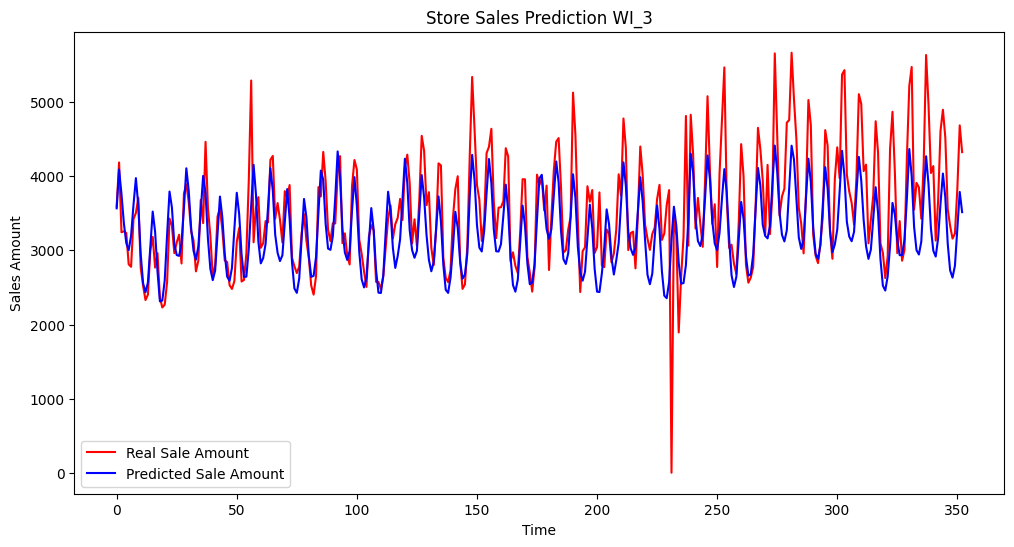

Train Done-----------------------------------------

Metrics Comparison Across All Stores:
          RMSE       MAE          MAPE      SMAPE        R²      NRMSE
CA_1  0.072131  0.051587  5.495802e+16   8.278465  0.694737  11.300307
CA_2  0.207304  0.175261  4.473797e+00  23.123782  0.147753  25.486422
CA_3  0.067005  0.046585  3.706114e+00   7.239938  0.648523   9.945887
CA_4  0.073776  0.050843  3.044790e+16   7.086986  0.421973   9.867668
TX_1  0.082357  0.059343  8.101626e+00   9.455968  0.514773  12.272973
TX_2  0.082432  0.057116  4.557848e+16   9.775452  0.415034  13.296312
TX_3  0.085455  0.058349  3.364999e+00   8.120407  0.470289  11.338681
WI_1  0.074558  0.054170  5.274718e+00  10.869361  0.590039  14.308575
WI_2  0.104981  0.078056  1.066954e+01  11.042014  0.577359  14.425684
WI_3  0.090551  0.066969  9.015375e+00  11.720968  0.454957  15.575692


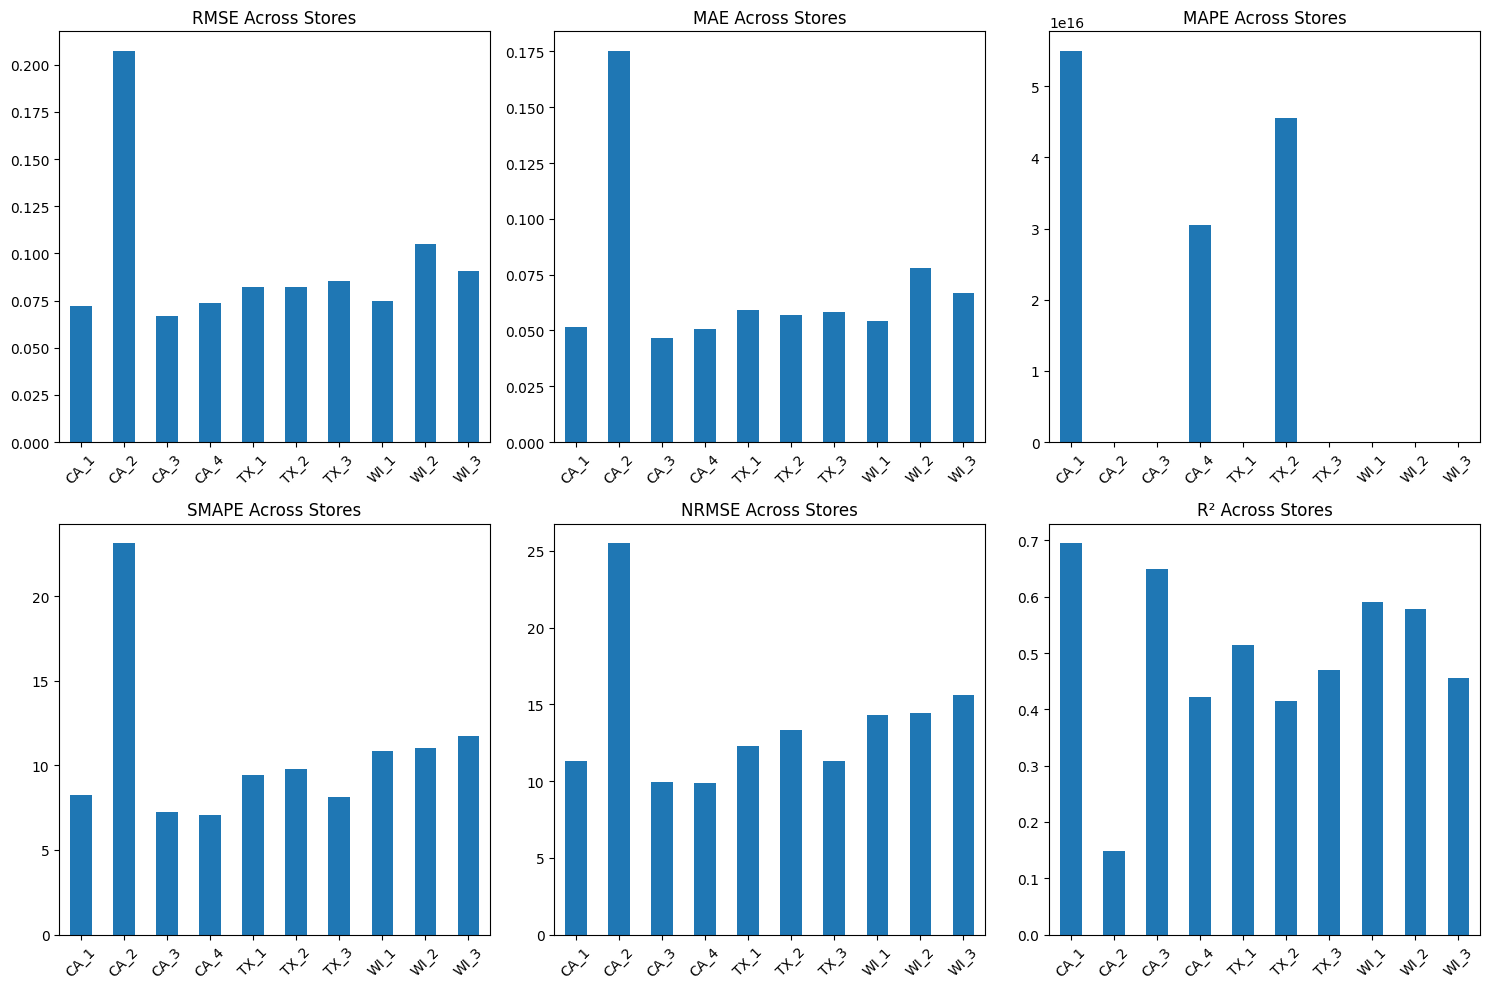

In [ ]:
#%%

dir = "../data/df_encoded.csv"
df = pd.read_csv(dir)
store_list = df["store_id"].unique()
scaler = MinMaxScaler(feature_range=(0,1))
metrics_results = {}
features = {}
for store in store_list:
    print(f"Training begin {store}--------------------------------")
    trainX, trainY, testX, testY = prepare_data(dir, store)
    grid_search = train_model(build_model, trainX, trainY)
    my_model = grid_search.best_estimator_.model_
    
    feature_cols = [col for col in df.columns if col not in ['store_id', 'sold','count']]
    
    # Calculate and store feature importance
    feature_importance = calculate_feature_importance(store, my_model, testX, testY, feature_cols)
    
    # Store in your metrics results
    features[store] = {'features': feature_importance}


    # Make predictions
    predictions = my_model.predict(testX)
    
    # Inverse transform for actual values (same as your original code)
    prediction_copies_array = np.repeat(predictions, 64, axis=-1)
    pred = scaler.inverse_transform(np.reshape(prediction_copies_array, (len(predictions), 64)))[:,0]
    
    original_copies_array = np.repeat(testY, 64, axis=-1)
    original = scaler.inverse_transform(np.reshape(original_copies_array, (len(testY), 64)))[:,0]
    
    # Calculate multiple evaluation metrics
    # 1. RMSE - Root Mean Squared Error
    rmse = np.sqrt(mean_squared_error(testY, predictions))
    
    # 2. MAE - Mean Absolute Error
    mae = mean_absolute_error(testY, predictions)
    
    # 3. MAPE - Mean Absolute Percentage Error (on original scale)
    # Avoiding division by zero
    mape = mean_absolute_percentage_error(original, pred)
    
    # 4. R² - Coefficient of Determination
    r2 = r2_score(testY, predictions)
    
    # 5. NRMSE - Normalized RMSE (as percentage of the mean)
    nrmse = rmse / np.mean(testY) * 100
    
    # 6. SMAPE - Symmetric Mean Absolute Percentage Error
    smape = 100/len(original) * np.sum(2 * np.abs(pred - original) / (np.abs(original) + np.abs(pred)))
    
    # Store all metrics
    metrics_results[store] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'SMAPE': smape,
        'R²': r2,
        'NRMSE': nrmse
    }
    
    # Print metrics
    print(f"Evaluation Metrics for Store {store}:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f} or {mape*100:.2f}%")
    print(f"SMAPE: {smape:.2f}%")
    print(f"R²: {r2:.4f}")
    print(f"NRMSE: {nrmse:.2f}%")
    
    # Plot actual vs predicted values (same as your original code)
    plt.figure(figsize=(12, 6))
    plt.plot(original, color='red', label='Real Sale Amount')
    plt.plot(pred, color='blue', label='Predicted Sale Amount')
    plt.title(f'Store Sales Prediction {store}')
    plt.xlabel('Time')
    plt.ylabel('Sales Amount')
    plt.legend()
    plt.show()
    
    print("Train Done-----------------------------------------")

# Create a comparison table of metrics across all stores
metrics_df = pd.DataFrame(metrics_results).T
print("\nMetrics Comparison Across All Stores:")
print(metrics_df)

# Plot metrics comparison
plt.figure(figsize=(15, 10))
metrics_to_plot = ['RMSE', 'MAE', 'MAPE', 'SMAPE', 'NRMSE']

for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 3, i)
    metrics_df[metric].plot(kind='bar')
    plt.title(f'{metric} Across Stores')
    plt.xticks(rotation=45)
    plt.tight_layout()

# Plot R² separately (as it has a different scale)
plt.subplot(2, 3, 6)
metrics_df['R²'].plot(kind='bar')
plt.title('R² Across Stores')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('metrics_comparison.png')
plt.show()

In [ ]:
print("finish")

finish
